# Actividad Modelos de Regresión 

### Integrantes 
#### Yeison David Toro - Juan Sebastian Ulloa

### Descripción  Actividad 
 La actividad presenta un problema real de predicción del impuesto predial a partir de información asociada a inmuebles ubicados en la ciudad de Bogotá. Para ello, se dispone de dos conjuntos de datos de entrenamiento y prueba, que contienen variables relacionadas con las características físicas, económicas y de localización de los inmuebles. Ambos conjuntos comparten la misma estructura, y el significado de cada atributo se encuentra documentado en un diccionario de datos.
    
El objetivo del reto es formular este escenario como un problema de regresión, en el cual se busca estimar un valor numérico continuo a partir de múltiples variables explicativas. Este caso permite analizar cómo el uso de técnicas de regularización contribuye a controlar la complejidad del modelo, reducir el sobreajuste y mejorar la capacidad de generalización, aspectos fundamentales cuando se trabaja con datos reales y de alta dimensionalidad.

#### Desarollo

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats
from itertools import combinations
from xgboost import XGBRegressor
import re
#from pycaret.classification import setup, compare_models, create_model, tune_model, plot_model, evaluate_model, finalize_model, predict_model, save_model, load_model
import warnings
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split, GridSearchCV
warnings.filterwarnings("ignore")

In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

#### 1. Cargue el conjunto de datos suministrado para el problema de regresión.

In [4]:
path = "../databases/"

#### 2. Realice la separación de los datos en conjuntos de entrenamiento y prueba.

In [5]:
%%time
#lectutra de fuente de datos 
df = pd.read_csv(path  + 'train.csv', sep=';', header=0, decimal=',')
prueba = pd.read_csv(path + "test.csv",sep=';',header=0, decimal=',')

df.head(2)


CPU times: user 2.07 s, sys: 234 ms, total: 2.31 s
Wall time: 7.85 s


,PRENBARRIO,PRECPREDIO,PRECCONS,PRECRESTO,PRECEDCATA,PRENUPRE,PRETPROP,PREFINCORP,PRECLASE,PREDIRECC,...,PRECENCHAP,PRECMOBILI,PRECCONSE,PRECINDUS,PREACERCHA,PRECLCONS,Latitud,Longitud,Clase_Barrio,y
0,LAS VILLAS,22.01,6,2001,009122082200602001,110010191112200080022906020001,6,2002/12/31,P,KR 58D 128B 01 IN 6 AP 201,...,424.0,432.0,442.0,NaN,NaN,R,58,4.031405,Clase 11,8.876465e+05
1,SANTA ROSA,43.01,5,11002,005402374300511002,110010154110200370043905110002,6,2011/12/22,P,CL 86A 69T 81 ET 4 IN 5 AP 1102,...,424.0,433.0,444.0,0.0,0.0,R,77,4.464988,Clase 16,1.587704e+06


 Remplazar caracteres _ en los conjuntos de datos

In [6]:
df.columns = [col.replace('_', '') for col in df.columns]
df.shape

(144244, 50)

In [7]:
df.head(2)

,PRENBARRIO,PRECPREDIO,PRECCONS,PRECRESTO,PRECEDCATA,PRENUPRE,PRETPROP,PREFINCORP,PRECLASE,PREDIRECC,...,PRECENCHAP,PRECMOBILI,PRECCONSE,PRECINDUS,PREACERCHA,PRECLCONS,Latitud,Longitud,ClaseBarrio,y
0,LAS VILLAS,22.01,6,2001,009122082200602001,110010191112200080022906020001,6,2002/12/31,P,KR 58D 128B 01 IN 6 AP 201,...,424.0,432.0,442.0,NaN,NaN,R,58,4.031405,Clase 11,8.876465e+05
1,SANTA ROSA,43.01,5,11002,005402374300511002,110010154110200370043905110002,6,2011/12/22,P,CL 86A 69T 81 ET 4 IN 5 AP 1102,...,424.0,433.0,444.0,0.0,0.0,R,77,4.464988,Clase 16,1.587704e+06


 Remplazar caracteres _ en los conjuntos de datos

In [8]:
prueba.columns = [col.replace('_', '') for col in prueba.columns]
prueba.shape

(99991, 50)

In [9]:
prueba.head(2)

,PRENBARRIO,PRECPREDIO,PRECCONS,PRECRESTO,PRECEDCATA,PRENUPRE,PRETPROP,PREFINCORP,PRECLASE,PREDIRECC,...,PRECENCHAP,PRECMOBILI,PRECCONSE,PRECINDUS,PREACERCHA,PRECLCONS,Latitud,Longitud,ClaseBarrio,y
0,LAS BRISAS,1.01,9,3003,001101090100903003,110010111040100090001909030003,6,1997/12/31,P,KR 7 6 16 SUR IN 9 AP 303,...,424.0,433.0,441.0,0.0,0.0,R,48,3.914221,Clase 1,599335.913749
1,LAS BRISAS,1.01,4,5002,001101090100405002,110010111040100090001904050002,6,1997/12/31,P,KR 7 6 16 SUR IN 4 AP 502,...,424.0,433.0,441.0,0.0,0.0,R,48,3.914221,Clase 1,576293.145277


In [10]:
diccionario = pd.read_excel(path + "diccionario.xlsx")
diccionario.columns = [col.replace('_', '') for col in diccionario.columns]
diccionario.head(2)

,Variable,Descripción
0,PRENBARRIO,Nombre del barrio donde se ubica el predio
1,PRECPREDIO,Índice de valorización del predio


 Data Entrenamiento

In [11]:
ft= pd.DataFrame(df.isnull().sum()).reset_index()
ft.columns = ['Variable','faltantes']
ft["% faltantes"] = ft["faltantes"] / df.shape[0] * 100
zoom = ft.copy()
zoom = pd.merge(zoom, diccionario, on='Variable', how='left')
zoom.loc[zoom["% faltantes"]>0]

,Variable,faltantes,% faltantes,Descripción
11,PRETDIRECC,96304,66.764649,Siglas de la dirección del inmueble
12,PREDSI,96304,66.764649,Identificación de la dirección del inmueble
15,PRECZHF,1,0.000693,Identificación DANE
27,PREEARMAZ,185,0.128255,Índice de calidad del predio
28,PREEMUROS,482,0.334156,Índice de calidad de la resistencia del materi...
29,PREECUBIER,158,0.109537,Índice de calidad de la resistencia del materi...
30,PREECONS,231,0.160145,Índice de calidad de la resistencia de la cons...
32,PREACUBIER,365,0.253043,índice de resistencia del exterior de la fachada
33,PREAPISOS,1,0.000693,Índice de calidad del material de los pisos
34,PREACONS,92,0.063781,Índice de amenaza y vulnerabilidad ante evento...


Segementación de las variables validas para estudio

In [12]:
variables_no_validas = list(zoom.loc[(zoom["% faltantes"]>0) & (zoom["Descripción"]=="No se informa el contenido de la variable y no es de uso del modelo"),]["Variable"])
variables_no_validas = variables_no_validas + ["PRETDIRECC","PREDSI","PRECEDCATA","PRENUPRE","PREDSI","PRECZHF","PREDIRECC","PREFCALIF","PREFINCORP","PREFCALIF","PRENBARRIO","PRECLCONS" ]
variables_no_validas = list(set(variables_no_validas))
variables_validas = [x for x in df.columns if x not in variables_no_validas]


In [13]:
df = df.get(variables_validas)
prueba = prueba.get(variables_validas)

print("La dimensión de históricos es:", df.shape)
print("La dimensión de prueba es:", prueba.shape)

len(variables_validas)


La dimensión de históricos es: (144244, 32)
La dimensión de prueba es: (99991, 32)


32

#### Regularizacion de variables

In [14]:
df['ClaseBarrio'] = df['ClaseBarrio'].str.extract('(\d+)').astype(int)
prueba['ClaseBarrio'] = prueba['ClaseBarrio'].str.extract('(\d+)').astype(int)

In [15]:
ft = pd.DataFrame(df.isnull().sum()).reset_index()
ft.columns = ["Variable","faltantes"]
ft["% faltantes"] = ft["faltantes"] * 100 / df.shape[0]
ft.loc[ft["% faltantes"]>0]

,Variable,faltantes,% faltantes
18,PREEARMAZ,185,0.128255
19,PREEMUROS,482,0.334156
20,PREECUBIER,158,0.109537
21,PREECONS,231,0.160145
23,PREACUBIER,365,0.253043
24,PREAPISOS,1,0.000693
25,PREACONS,92,0.063781
26,PREBTAMANO,15,0.010399


In [16]:
formato = pd.DataFrame({'Variable': list(df.columns), 'Formato': df.dtypes })
ft = pd.merge(ft,formato,on=["Variable"],how="left")
ft.head()

,Variable,faltantes,% faltantes,Formato
0,PRECPREDIO,0,0.0,float64
1,PRECCONS,0,0.0,int64
2,PRECRESTO,0,0.0,int64
3,PRETPROP,0,0.0,int64
4,PRECLASE,0,0.0,str


In [17]:
ft.loc[ft["% faltantes"]>0]

,Variable,faltantes,% faltantes,Formato
18,PREEARMAZ,185,0.128255,float64
19,PREEMUROS,482,0.334156,float64
20,PREECUBIER,158,0.109537,float64
21,PREECONS,231,0.160145,float64
23,PREACUBIER,365,0.253043,float64
24,PREAPISOS,1,0.000693,float64
25,PREACONS,92,0.063781,float64
26,PREBTAMANO,15,0.010399,float64


 Inputacion de datos faltantes datos entrenamiento

In [18]:
lista_faltantes = list(ft.loc[ft["% faltantes"]>0,]["Variable"])
lista_faltantes

['PREEARMAZ',
 'PREEMUROS',
 'PREECUBIER',
 'PREECONS',
 'PREACUBIER',
 'PREAPISOS',
 'PREACONS',
 'PREBTAMANO']

In [19]:
for k in lista_faltantes:
    mediana_variable = df[k].median()
    df.loc[df[k].isnull()==True,k] = mediana_variable

In [20]:
ft = pd.DataFrame(df.isnull().sum()).reset_index()
ft.columns = ["Variable","Faltantes"]
ft["% faltantes"] = ft["Faltantes"] * 100 / df.shape[0]
ft.loc[ft["% faltantes"]>0]

,Variable,Faltantes,% faltantes


In [21]:
formato = pd.DataFrame({'Variable': list(df.columns), 'Formato': df.dtypes })
ft = pd.merge(ft,formato,on=["Variable"],how="left")
ft.head()

,Variable,Faltantes,% faltantes,Formato
0,PRECPREDIO,0,0.0,float64
1,PRECCONS,0,0.0,int64
2,PRECRESTO,0,0.0,int64
3,PRETPROP,0,0.0,int64
4,PRECLASE,0,0.0,str


 Data Pruebas

In [22]:
ft2 = pd.DataFrame(prueba.isnull().sum()).reset_index()
ft2.columns = ["Variable","Faltantes"]
ft2["% faltantes"] = ft2["Faltantes"] * 100 / prueba.shape[0]
ft2.loc[ft2["% faltantes"]>0]

,Variable,Faltantes,% faltantes
18,PREEARMAZ,137,0.137012
19,PREEMUROS,339,0.339031
20,PREECUBIER,113,0.113010
21,PREECONS,167,0.167015
22,PREAFACHAD,1,0.001000
23,PREACUBIER,247,0.247022
24,PREAPISOS,2,0.002000
25,PREACONS,71,0.071006
26,PREBTAMANO,6,0.006001


 Inputacion de datos faltantes pruebas

In [23]:
lista_faltantes2 = list(ft2.loc[ft2["% faltantes"]>0,]["Variable"])
lista_faltantes2

['PREEARMAZ',
 'PREEMUROS',
 'PREECUBIER',
 'PREECONS',
 'PREAFACHAD',
 'PREACUBIER',
 'PREAPISOS',
 'PREACONS',
 'PREBTAMANO']

In [24]:
for k in lista_faltantes2:
    mediana_variable2 = prueba[k].median()
    prueba.loc[prueba[k].isnull()==True,k] = mediana_variable2

In [25]:
ft2 = pd.DataFrame(prueba.isnull().sum()).reset_index()
ft2.columns = ["Variable","Faltantes"]
ft2["% faltantes"] = ft2["Faltantes"] * 100 / prueba.shape[0]
ft2.loc[ft2["% faltantes"]>0]

,Variable,Faltantes,% faltantes


In [26]:
formato

,Variable,Formato
PRECPREDIO,PRECPREDIO,float64
PRECCONS,PRECCONS,int64
PRECRESTO,PRECRESTO,int64
PRETPROP,PRETPROP,int64
PRECLASE,PRECLASE,str
PREMDIRECC,PREMDIRECC,str
PREATERRE,PREATERRE,float64
PREACONST,PREACONST,float64
PRECDESTIN,PRECDESTIN,int64
PREVETUSTZ,PREVETUSTZ,int64


Análisis descriptivo

In [27]:
cuantitativas = list(formato.loc[formato["Formato"]!="str","Variable"])
cuantitativas = [x for x in cuantitativas if x not in ["y"]]

cualitativas = list(formato.loc[formato["Formato"]=="str","Variable"])
cualitativas = [x for x in cualitativas if x not in ["y"]]

In [28]:
df.get(cuantitativas).head(2)

,PRECPREDIO,PRECCONS,PRECRESTO,PRETPROP,PREATERRE,PREACONST,PRECDESTIN,PREVETUSTZ,PREVFORMA,PREVACTUAL,...,PREECONS,PREAFACHAD,PREACUBIER,PREAPISOS,PREACONS,PREBTAMANO,PREBENCHAP,Latitud,Longitud,ClaseBarrio
0,22.01,6,2001,6,39.39,88.33,1,2002,1995,2024,...,144.0,213,223.0,235.0,242.0,312.0,324,58,4.031405,11
1,43.01,5,11002,6,33.45,118.91,1,2011,1994,2024,...,144.0,213,223.0,236.0,244.0,312.0,324,77,4.464988,16


In [29]:
df.get(cualitativas).head(2)

,PRECLASE,PREMDIRECC,PREUSOPH,PREUSONPH,PREUVIVIEN,PREUCALIF
0,P,D,S,N,S,A
1,P,D,S,N,S,H


In [30]:
df_auxiliar = df.copy()
df_auxiliar["log_y"] = np.log(df_auxiliar["y"])

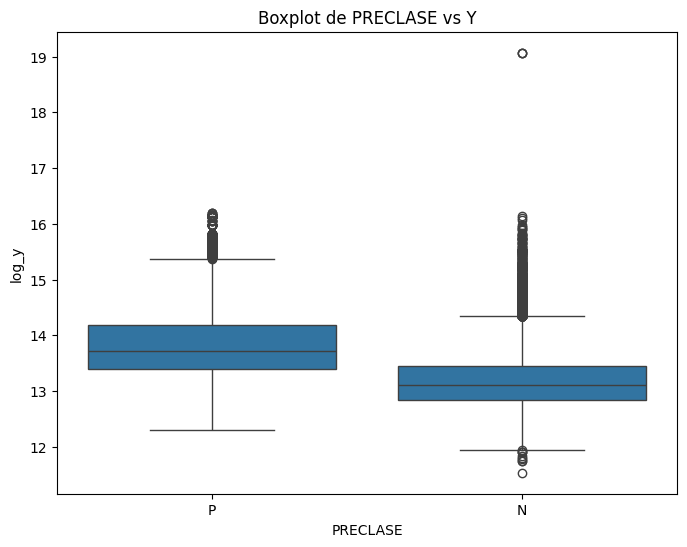

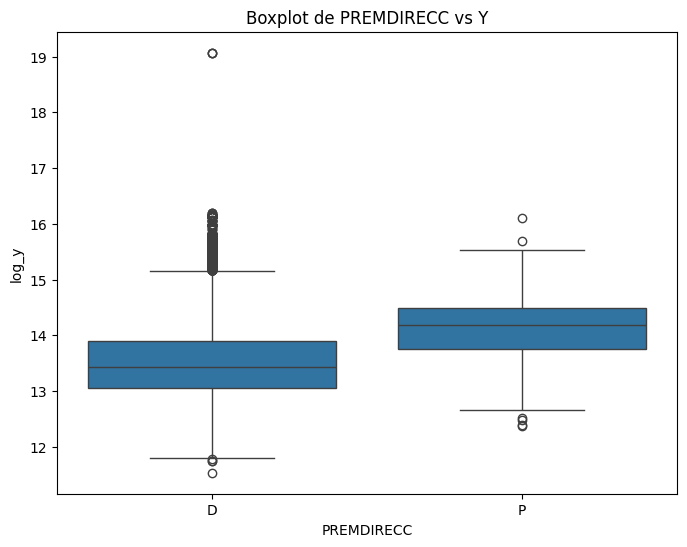

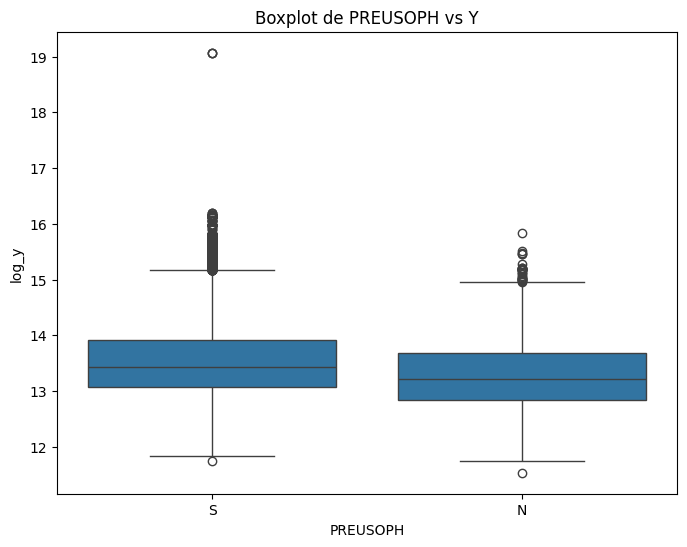

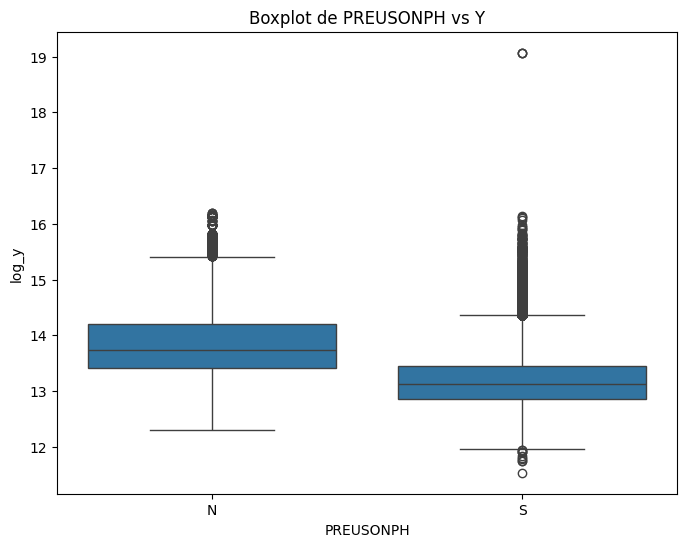

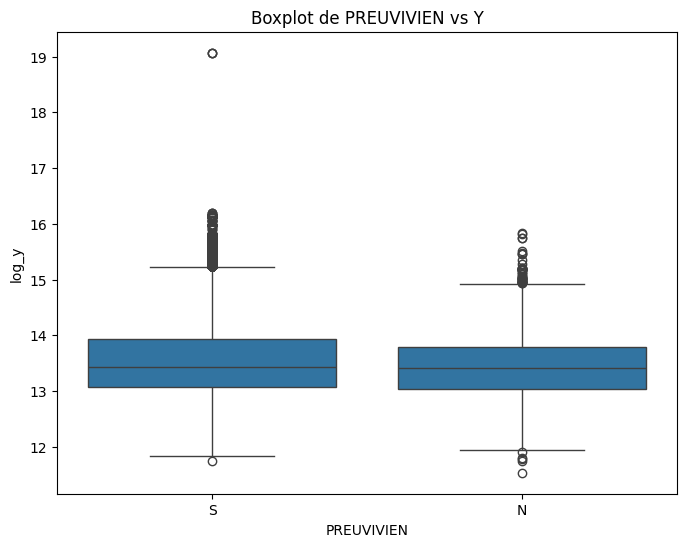

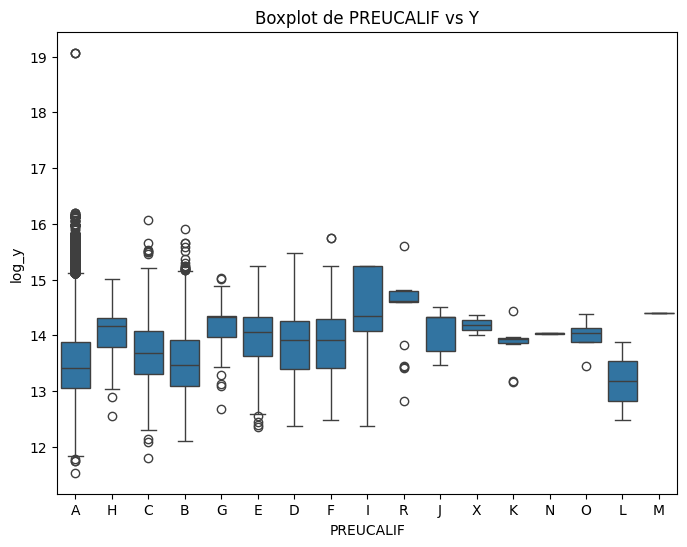

In [31]:
for k in cualitativas:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=k,y="log_y",data=df_auxiliar)
    plt.title("Boxplot de "+k+" vs Y")

In [32]:
grupos_variables = [cuantitativas[0:12] + ["y"]] + [cuantitativas[12:25] + ["y"]]

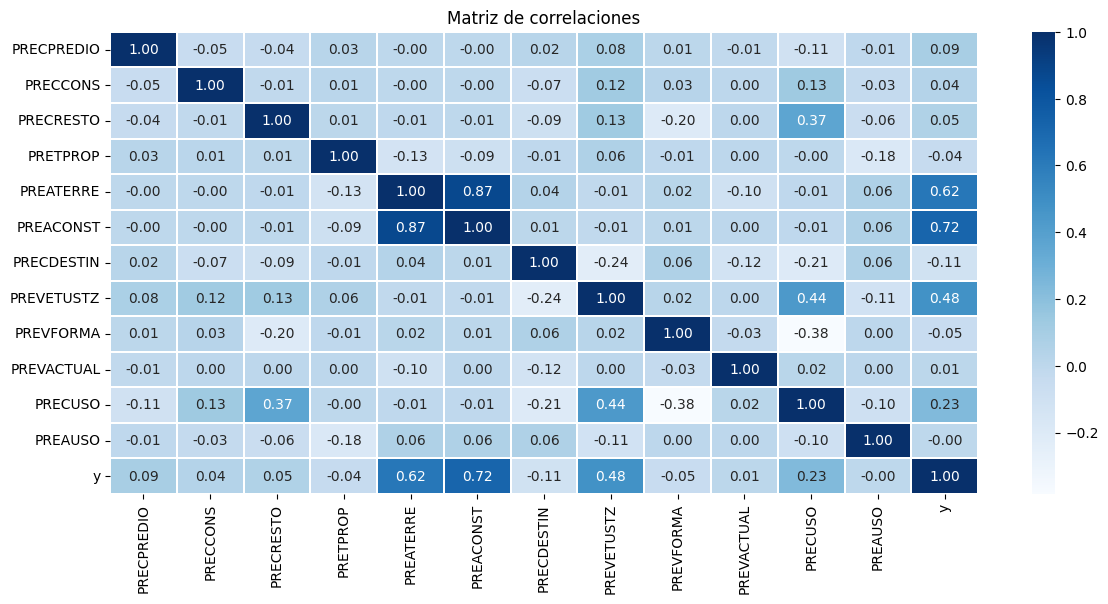

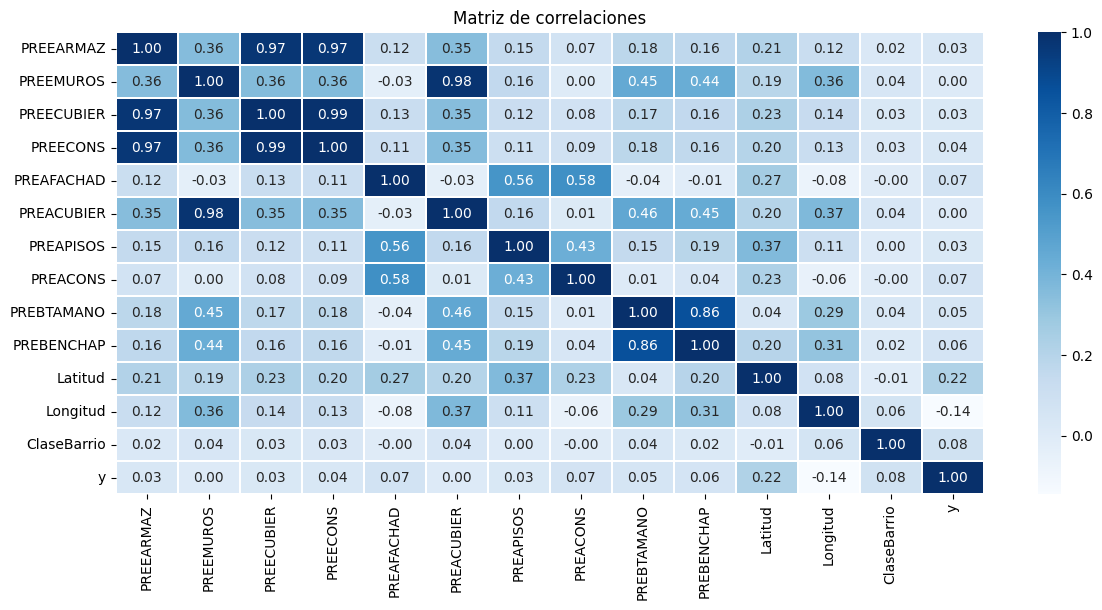

In [33]:
for k in grupos_variables:
    correlaciones = df.get(k).corr()
    plt.figure(figsize=(14,6))
    sns.heatmap(correlaciones, linewidths=0.01, cmap="Blues", annot=True, fmt=".2f")
    plt.title("Matriz de correlaciones")
    plt.show()

#### Ingenierí­a de variables

In [34]:
df["y"].describe()

count    1.442440e+05
mean     9.503339e+05
std      1.205716e+06
min      1.024078e+05
25%      4.723999e+05
50%      6.793921e+05
75%      1.096840e+06
max      1.910223e+08
Name: y, dtype: float64

In [35]:
base_cuadrado = df[cuantitativas].copy()
base_cuadrado["y"] = df["y"].copy()

var_names2, correlaciones = [], []

for k in cuantitativas:
    base_cuadrado[k + "_2"] = base_cuadrado[k] ** 2

    # Calcular correlaciÃƒÂ³n de la variable al cuadrado con Target
    corr = base_cuadrado[[k + "_2", "y"]].corr().iloc[0, 1]
    
    # Guardar correlaciÃƒÂ³n y variable
    var_names2.append(k + "_2")
    correlaciones.append(np.round(corr, 2))

 variables al cuadrado

In [36]:
base_cuadrado.head(2)

,PRECPREDIO,PRECCONS,PRECRESTO,PRETPROP,PREATERRE,PREACONST,PRECDESTIN,PREVETUSTZ,PREVFORMA,PREVACTUAL,...,PREECONS_2,PREAFACHAD_2,PREACUBIER_2,PREAPISOS_2,PREACONS_2,PREBTAMANO_2,PREBENCHAP_2,Latitud_2,Longitud_2,ClaseBarrio_2
0,22.01,6,2001,6,39.39,88.33,1,2002,1995,2024,...,20736.0,45369,49729.0,55225.0,58564.0,97344.0,104976,3364,16.252224,121
1,43.01,5,11002,6,33.45,118.91,1,2011,1994,2024,...,20736.0,45369,49729.0,55696.0,59536.0,97344.0,104976,5929,19.936119,256


Variables P^2 con correlacion Mayor a .5

In [37]:
pcuadrado1 = pd.DataFrame({'Variable2':var_names2,'correlacion':correlaciones})
pcuadrado1['criterio'] = pcuadrado1['correlacion'].apply(lambda x: 1 if abs(x) > 0.5 else 0)
pcuadrado1.loc[pcuadrado1["criterio"]==1,].head(10)


,Variable2,correlacion,criterio
4,PREATERRE_2,0.71,1
5,PREACONST_2,0.72,1


#### Interacciones cuantitativas

In [38]:
lista_inter = list(combinations(cuantitativas,2))
base_interacciones = df.get(cuantitativas).copy()
base_interacciones["y"] = df["y"].copy()

var_interaccion, correlaciones = [], []
for k in lista_inter:
    col_name = k[0] + "__" + k[1]
    base_interacciones[col_name] = base_interacciones[k[0]] * base_interacciones[k[1]]

    corr = base_interacciones[[col_name, "y"]].corr().iloc[0, 1]
    var_interaccion.append(col_name)
    correlaciones.append(np.round(corr, 2))

pxy = pd.DataFrame({'Variable':var_interaccion, 'correlacion':correlaciones})
pxy['criterio'] = pxy['correlacion'].apply(lambda x: 1 if abs(x) > 0.5 else 0)
pxy = pxy.sort_values('correlacion', ascending=False).reset_index(drop=True)
pxy.head()

,Variable,correlacion,criterio
0,PRECPREDIO__PREACONST,0.72,1
1,PREACONST__PREEARMAZ,0.72,1
2,PREACONST__PREVACTUAL,0.72,1
3,PREACONST__PREVETUSTZ,0.72,1
4,PREACONST__PREVFORMA,0.72,1


In [39]:
list(pxy["Variable"])

['PRECPREDIO__PREACONST',
 'PREACONST__PREEARMAZ',
 'PREACONST__PREVACTUAL',
 'PREACONST__PREVETUSTZ',
 'PREACONST__PREVFORMA',
 'PREACONST__PREAFACHAD',
 'PREACONST__PREECONS',
 'PREACONST__PREBENCHAP',
 'PREACONST__PREBTAMANO',
 'PREACONST__PREACONS',
 'PREACONST__PREAPISOS',
 'PREACONST__PREACUBIER',
 'PREACONST__ClaseBarrio',
 'PREACONST__Latitud',
 'PREACONST__Longitud',
 'PREACONST__PREECUBIER',
 'PREACONST__PREEMUROS',
 'PREATERRE__PREACONST',
 'PREACONST__PRECDESTIN',
 'PREATERRE__PREBENCHAP',
 'PRETPROP__PREACONST',
 'PREATERRE__PREBTAMANO',
 'PREATERRE__Latitud',
 'PREATERRE__Longitud',
 'PREATERRE__ClaseBarrio',
 'PREATERRE__PREACUBIER',
 'PREATERRE__PREEMUROS',
 'PREATERRE__PREECUBIER',
 'PREATERRE__PREEARMAZ',
 'PREATERRE__PREAFACHAD',
 'PREATERRE__PREECONS',
 'PREATERRE__PREAPISOS',
 'PREATERRE__PREACONS',
 'PREATERRE__PREVACTUAL',
 'PREATERRE__PREVETUSTZ',
 'PREATERRE__PREVFORMA',
 'PRECPREDIO__PREATERRE',
 'PREACONST__PREAUSO',
 'PRECRESTO__PREATERRE',
 'PREVETUSTZ__PRE

#### Razones

In [40]:
raz1 = [(x, y) for x in cuantitativas for y in cuantitativas]
base_razones1 = df[cuantitativas].copy()
base_razones1["y"] = df["y"].copy()

var_nm, correlaciones = [], []
for j in raz1:
    if j[0] != j[1]:
        nombre_var = j[0] + "__coc__" + j[1]
        base_razones1[nombre_var] = base_razones1[j[0]] / (base_razones1[j[1]] + 0.01)

        corr = base_razones1[[nombre_var, "y"]].corr().iloc[0, 1]

        var_nm.append(nombre_var)
        correlaciones.append(np.round(corr, 2))

In [41]:
prazones = pd.DataFrame({'Variable': var_nm, 'correlacion': correlaciones})
prazones['criterio'] = prazones['correlacion'].apply(lambda x: 1 if abs(x) > 0.5 else 0)
prazones_filtrado = prazones.iloc[(prazones['criterio'] == 1).to_numpy()]
prazones_filtrado.head()

,Variable,correlacion,criterio
97,PREATERRE__coc__PRECCONS,0.62,1
99,PREATERRE__coc__PRETPROP,0.67,1
101,PREATERRE__coc__PRECDESTIN,0.64,1
102,PREATERRE__coc__PREVETUSTZ,0.62,1
103,PREATERRE__coc__PREVFORMA,0.62,1


#### Interacciones categóricas

In [42]:
categoricas = list(formato.loc[formato["Formato"]=="str","Variable"])
categoricas = [x for x in categoricas if x not in ["y"]]

def nombre_(x):
  return "C"+str(x)

categoricas

['PRECLASE', 'PREMDIRECC', 'PREUSOPH', 'PREUSONPH', 'PREUVIVIEN', 'PREUCALIF']

In [43]:
cb = list(combinations(categoricas,2))
p_value, modalidades, nombre_var = [], [], []

base2 = df.get(categoricas).copy()
for k in base2.columns:
  base2[k] = base2[k].map(nombre_)

base2["y"] = df["y"].copy()

for k in range(len(cb)):
    # Variable con interacciÃƒÂ³n
    base2[cb[k][0]] = base2[cb[k][0]]
    base2[cb[k][1]] = base2[cb[k][1]]

    nombre_interaccion = cb[k][0] + "__" + cb[k][1]
    base2[nombre_interaccion] = base2[cb[k][0]] + "__" + base2[cb[k][1]]

    # Kruskal entre todas las combinaciones de modalidades
    mods = base2[nombre_interaccion].dropna().unique()
    pares_mods = list(combinations(mods, 2))
    pvals_mods = []

    for par in pares_mods:
        m1 = base2.loc[base2[nombre_interaccion] == par[0], "y"].dropna().to_numpy()
        m2 = base2.loc[base2[nombre_interaccion] == par[1], "y"].dropna().to_numpy()

        if len(m1) > 0 and len(m2) > 0:
            pv = stats.kruskal(m1, m2)[1]
            pvals_mods.append(pv)

    pv_min = np.min(pvals_mods) if len(pvals_mods) > 0 else np.nan

    # Numero de modalidades por categoria 
    mod_ = len(mods)

    # Guardar p value minimo y modalidades
    nombre_var.append(nombre_interaccion)
    modalidades.append(mod_)
    p_value.append(pv_min)

In [44]:
pc = pd.DataFrame({'Variable':nombre_var,'Num Modalidades':modalidades,'p value':p_value})
pc.loc[(pc["p value"]<=0.20) & (pc["Num Modalidades"]<=15),].sort_values(["p value"],ascending=True).head()

,Variable,Num Modalidades,p value
0,PRECLASE__PREMDIRECC,3,0.0
1,PRECLASE__PREUSOPH,4,0.0
2,PRECLASE__PREUSONPH,4,0.0
3,PRECLASE__PREUVIVIEN,4,0.0
6,PREMDIRECC__PREUSONPH,3,0.0


#### Dummies categóricas más significativas (p value <= 0.20 y bajo número de modalidades)

In [45]:
def indicadora(x):
  if x==True:
    return 1
  else:
    return 0

seleccion1 = list(pc.loc[(pc["p value"]<=0.20) & (pc["Num Modalidades"]<=15),"Variable"])
sel1 = base2.get(seleccion1)

contador = 0
for k in sel1:
    if contador==0:
        lb1 = pd.get_dummies(sel1[k],drop_first=True)
        lb1.columns = [k + "_" + x for x in lb1.columns]
    else:
        lb2 = pd.get_dummies(sel1[k],drop_first=True)
        lb2.columns = [k + "_" + x for x in lb2.columns]
        lb1 = pd.concat([lb1,lb2],axis=1)
    contador = contador + 1

for k in lb1.columns:
  lb1[k] = lb1[k].map(indicadora)

lb1["y"] = df["y"].copy()
lb1.head(3)

,PRECLASE__PREMDIRECC_CN__CP,PRECLASE__PREMDIRECC_CP__CD,PRECLASE__PREUSOPH_CN__CS,PRECLASE__PREUSOPH_CP__CN,PRECLASE__PREUSOPH_CP__CS,PRECLASE__PREUSONPH_CN__CS,PRECLASE__PREUSONPH_CP__CN,PRECLASE__PREUSONPH_CP__CS,PRECLASE__PREUVIVIEN_CN__CS,PRECLASE__PREUVIVIEN_CP__CN,...,PREMDIRECC__PREUVIVIEN_CP__CN,PREMDIRECC__PREUVIVIEN_CP__CS,PREUSOPH__PREUSONPH_CS__CN,PREUSOPH__PREUSONPH_CS__CS,PREUSOPH__PREUVIVIEN_CS__CN,PREUSOPH__PREUVIVIEN_CS__CS,PREUSONPH__PREUVIVIEN_CN__CS,PREUSONPH__PREUVIVIEN_CS__CN,PREUSONPH__PREUVIVIEN_CS__CS,y
0,0,1,0,0,1,0,1,0,0,0,...,0,0,1,0,0,1,1,0,0,8.876465e+05
1,0,1,0,0,1,0,1,0,0,0,...,0,0,1,0,0,1,1,0,0,1.587704e+06
2,0,0,1,0,0,1,0,0,1,0,...,0,0,0,1,0,1,0,0,1,3.177846e+05


#### Interacción cuantitativa vs categórica

In [46]:
cat_cuanti = [(x,y) for x in cuantitativas for y in categoricas]
cat_cuanti[0]

('PRECPREDIO', 'PRECLASE')

In [47]:
v1, v2, correlaciones_max = [], [], []

for j in cat_cuanti:
    k1 = j[0]
    k2 = j[1]

    g1 = pd.get_dummies(df[k2])
    lt1 = list(g1.columns)

    for k in lt1:
        g1[k] = g1[k] * df[k1]

    g1["y"] = df["y"].copy()

    correlaciones_c = []
    for y in lt1:
        corr = g1[[y, "y"]].corr().iloc[0, 1]
        correlaciones_c.append(np.round(corr, 2))

    max_ = np.max(np.abs(correlaciones_c)) # Se calcula la maxima correlacion absoluta por categoria
    v1.append(k1)
    v2.append(k2)
    correlaciones_max.append(np.round(max_,2))

In [48]:
pc2 = pd.DataFrame({'Cuantitativa': v1, 'Categorica': v2, 'correlacion': correlaciones_max})
pc2.loc[np.abs(pc2["correlacion"]) > 0.5,]

,Cuantitativa,Categorica,correlacion
24,PREATERRE,PRECLASE,0.62
25,PREATERRE,PREMDIRECC,0.62
26,PREATERRE,PREUSOPH,0.65
27,PREATERRE,PREUSONPH,0.62
28,PREATERRE,PREUVIVIEN,0.65
29,PREATERRE,PREUCALIF,0.65
30,PREACONST,PRECLASE,0.72
31,PREACONST,PREMDIRECC,0.72
32,PREACONST,PREUSOPH,0.72
33,PREACONST,PREUSONPH,0.72


#### Base de Feature Enginnering

In [49]:
v1 = list(pc2.loc[np.abs(pc2["correlacion"]) > 0.5, "Cuantitativa"])
v2 = list(pc2.loc[np.abs(pc2["correlacion"]) > 0.5, "Categorica"])

In [50]:
for j in range(len(v1)):

    if j==0:
        g1 = pd.get_dummies(df[v2[j]],drop_first=True)
        lt1 = list(g1.columns)
        for k in lt1:
            g1[k] = g1[k] * df[v1[j]]
        g1.columns = [v1[j] + "_" + v2[j] + "_" + str(x) for x in lt1]
    else:
        g2 = pd.get_dummies(df[v2[j]],drop_first=True)
        lt1 = list(g2.columns)
        for k in lt1:
            g2[k] = g2[k] * df[v1[j]]
        g2.columns = [v1[j] + "_" + v2[j] + "_" + str(x) for x in lt1]
        g1 = pd.concat([g1,g2],axis=1)

g1["y"] = df["y"].copy() 
g1.head(5)

,PREATERRE_PRECLASE_P,PREATERRE_PREMDIRECC_P,PREATERRE_PREUSOPH_S,PREATERRE_PREUSONPH_S,PREATERRE_PREUVIVIEN_S,PREATERRE_PREUCALIF_B,PREATERRE_PREUCALIF_C,PREATERRE_PREUCALIF_D,PREATERRE_PREUCALIF_E,PREATERRE_PREUCALIF_F,...,PREACONST_PREUCALIF_I,PREACONST_PREUCALIF_J,PREACONST_PREUCALIF_K,PREACONST_PREUCALIF_L,PREACONST_PREUCALIF_M,PREACONST_PREUCALIF_N,PREACONST_PREUCALIF_O,PREACONST_PREUCALIF_R,PREACONST_PREUCALIF_X,y
0,39.39,0.0,39.39,0.0,39.39,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.876465e+05
1,33.45,0.0,33.45,0.0,33.45,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.587704e+06
2,0.00,0.0,64.80,64.8,64.80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.177846e+05
3,0.00,0.0,99.80,99.8,99.80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.438812e+05
4,26.32,0.0,26.32,0.0,26.32,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.792528e+06


#### Selección de variables con XGBOOST

 variables al cuadrado

In [51]:
pcuadrado1.head()

,Variable2,correlacion,criterio
0,PRECPREDIO_2,0.10,0
1,PRECCONS_2,0.01,0
2,PRECRESTO_2,0.00,0
3,PRETPROP_2,-0.03,0
4,PREATERRE_2,0.71,1


In [52]:
var_cuad = list(pcuadrado1["Variable2"])
base_modelo1 = base_cuadrado.get(var_cuad+["y"])
base_modelo1.head()

,PRECPREDIO_2,PRECCONS_2,PRECRESTO_2,PRETPROP_2,PREATERRE_2,PREACONST_2,PRECDESTIN_2,PREVETUSTZ_2,PREVFORMA_2,PREVACTUAL_2,...,PREAFACHAD_2,PREACUBIER_2,PREAPISOS_2,PREACONS_2,PREBTAMANO_2,PREBENCHAP_2,Latitud_2,Longitud_2,ClaseBarrio_2,y
0,484.4401,36,4004001,36,1551.5721,7802.1889,1,4008004,3980025,4096576,...,45369,49729.0,55225.0,58564.0,97344.0,104976,3364,16.252224,121,8.876465e+05
1,1849.8601,25,121044004,36,1118.9025,14139.5881,1,4044121,3976036,4096576,...,45369,49729.0,55696.0,59536.0,97344.0,104976,5929,19.936119,256,1.587704e+06
2,4.0401,0,0,36,4199.0400,46828.9600,1,3880900,3988009,4096576,...,44944,49284.0,54289.0,58081.0,97344.0,104329,1369,27.218775,4,3.177846e+05
3,1.0201,0,0,36,9960.0400,13409.6400,1,3940225,3992004,4096576,...,44944,49284.0,54289.0,58081.0,97344.0,103684,900,19.612076,1,4.438812e+05
4,100.2001,4,1012036,36,692.7424,13646.9124,1,4064256,3968064,4096576,...,45369,49729.0,55696.0,59536.0,97344.0,104976,6084,19.719366,36,2.792528e+06


In [53]:
cov = list(base_modelo1.columns)
cov = [x for x in cov if x not in ["y"]]

X1 = base_modelo1.get(cov)
y1 = base_modelo1.get(["y"])

modelo1 = XGBRegressor()
modelo1 = modelo1.fit(X1,y1)

importancias = modelo1.feature_importances_
imp1 = pd.DataFrame({'Variable':X1.columns,'Importancia':importancias})
imp1["Importancia"] = imp1["Importancia"] * 100 / np.sum(imp1["Importancia"])
imp1 = imp1.sort_values(["Importancia"],ascending=False)
imp1.index = range(imp1.shape[0])
imp1.head()

,Variable,Importancia
0,PREATERRE_2,74.462639
1,PREVETUSTZ_2,23.821646
2,PREVFORMA_2,0.804030
3,PREACONST_2,0.174371
4,PREEARMAZ_2,0.114764


#### Interacciones cuantitativas

In [54]:
pxy.head()

,Variable,correlacion,criterio
0,PRECPREDIO__PREACONST,0.72,1
1,PREACONST__PREEARMAZ,0.72,1
2,PREACONST__PREVACTUAL,0.72,1
3,PREACONST__PREVETUSTZ,0.72,1
4,PREACONST__PREVFORMA,0.72,1


In [55]:
pxy["criterio"].value_counts()

criterio
0    261
1     39
Name: count, dtype: int64

In [56]:
var_int = list(pxy["Variable"])
base_modelo2 = base_interacciones.get(var_int+["y"])
base_modelo2.head()

,PRECPREDIO__PREACONST,PREACONST__PREEARMAZ,PREACONST__PREVACTUAL,PREACONST__PREVETUSTZ,PREACONST__PREVFORMA,PREACONST__PREAFACHAD,PREACONST__PREECONS,PREACONST__PREBENCHAP,PREACONST__PREBTAMANO,PREACONST__PREACONS,...,PREECONS__Longitud,PREEARMAZ__Longitud,PREECUBIER__Longitud,PREAPISOS__Longitud,PREACONS__Longitud,PREAFACHAD__Longitud,PREVACTUAL__Longitud,PREVFORMA__Longitud,PRETPROP__Longitud,y
0,1944.1433,10157.95,178779.92,176836.66,176218.35,18814.29,12719.52,28618.92,27558.96,21375.86,...,580.522286,463.611548,540.208238,947.380119,975.599953,858.689214,8159.563239,8042.652501,24.188429,8.876465e+05
1,5114.3191,13674.65,240673.84,239128.01,237106.54,25327.83,17123.04,38526.84,37099.92,29014.04,...,642.958294,513.473638,602.773401,1053.737205,1089.457110,951.042477,9037.136027,8903.186382,26.789929,1.587704e+06
2,434.9640,24453.20,437993.60,426308.00,432150.80,45876.80,30512.40,69897.20,67516.80,52152.40,...,735.619777,589.539254,693.882485,1215.598639,1257.335931,1106.038246,10559.534956,10418.671595,31.302969,3.177846e+05
3,116.9580,13085.40,234379.20,229863.00,231368.40,24549.60,16327.80,37287.60,36129.60,27907.80,...,624.425879,500.426414,588.997460,1031.852693,1067.281112,938.853094,8963.389920,8848.247560,26.571314,4.438812e+05
4,1169.3682,13434.30,236443.68,235509.12,232705.44,24882.66,16705.26,37849.68,36447.84,28504.08,...,635.012843,510.674664,599.487649,1047.993224,1083.518418,945.858291,8987.874090,8845.773314,26.643896,2.792528e+06


In [57]:
cov = list(base_modelo2.columns)
cov = [x for x in cov if x not in ["y"]]

X2 = base_modelo2.get(cov)
y2 = base_modelo2.get(["y"])

modelo2 = XGBRegressor()
modelo2 = modelo2.fit(X2,y2)

importancias = modelo2.feature_importances_
imp2 = pd.DataFrame({'Variable':X2.columns,'Importancia':importancias})
imp2["Importancia"] = imp2["Importancia"] * 100 / np.sum(imp2["Importancia"])
imp2 = imp2.sort_values(["Importancia"],ascending=False)
imp2.index = range(imp2.shape[0])
imp2.head()

,Variable,Importancia
0,PREACONST__PREVACTUAL,90.000687
1,PREVETUSTZ__PREVACTUAL,7.157822
2,PREEMUROS__ClaseBarrio,0.452603
3,PREVETUSTZ__PREEMUROS,0.366995
4,PREVFORMA__PREVACTUAL,0.239693


#### Razones

In [58]:
prazones.head()

,Variable,correlacion,criterio
0,PRECPREDIO__coc__PRECCONS,-0.16,0
1,PRECPREDIO__coc__PRECRESTO,-0.16,0
2,PRECPREDIO__coc__PRETPROP,0.10,0
3,PRECPREDIO__coc__PREATERRE,0.01,0
4,PRECPREDIO__coc__PREACONST,0.19,0


In [59]:
var_raz = list(prazones["Variable"])
base_modelo3 = base_razones1.get(var_raz+["y"])
base_modelo3.head()

,PRECPREDIO__coc__PRECCONS,PRECPREDIO__coc__PRECRESTO,PRECPREDIO__coc__PRETPROP,PRECPREDIO__coc__PREATERRE,PRECPREDIO__coc__PREACONST,PRECPREDIO__coc__PRECDESTIN,PRECPREDIO__coc__PREVETUSTZ,PRECPREDIO__coc__PREVFORMA,PRECPREDIO__coc__PREVACTUAL,PRECPREDIO__coc__PRECUSO,...,ClaseBarrio__coc__PREECONS,ClaseBarrio__coc__PREAFACHAD,ClaseBarrio__coc__PREACUBIER,ClaseBarrio__coc__PREAPISOS,ClaseBarrio__coc__PREACONS,ClaseBarrio__coc__PREBTAMANO,ClaseBarrio__coc__PREBENCHAP,ClaseBarrio__coc__Latitud,ClaseBarrio__coc__Longitud,y
0,3.66223,0.010999,3.662230,0.558629,0.249151,21.792079,0.010994,0.011033,0.010874,0.579058,...,0.076384,0.051641,0.049325,0.046807,0.045453,0.035255,0.033950,0.189622,2.721826,8.876465e+05
1,8.58483,0.003909,7.156406,1.285415,0.361672,42.584158,0.021387,0.021570,0.021250,1.131544,...,0.111103,0.075114,0.071746,0.067794,0.065571,0.051280,0.049381,0.207765,3.575428,1.587704e+06
2,201.00000,201.000000,0.334443,0.031014,0.009288,1.990099,0.001020,0.001007,0.000993,1.990099,...,0.014183,0.009434,0.009009,0.008583,0.008298,0.006410,0.006192,0.054039,0.382617,3.177846e+05
3,101.00000,101.000000,0.168053,0.010119,0.008721,1.000000,0.000509,0.000506,0.000499,1.000000,...,0.007092,0.004717,0.004504,0.004292,0.004149,0.003205,0.003105,0.033322,0.225299,4.438812e+05
4,4.98010,0.009950,1.665557,0.380175,0.085680,9.910891,0.004965,0.005025,0.004946,0.263352,...,0.041955,0.028168,0.026905,0.025423,0.024589,0.019230,0.018518,0.076913,1.348118,2.792528e+06


In [60]:
cov = list(base_modelo3.columns)
cov = [x for x in cov if x not in ["y"]]

X3 = base_modelo3.get(cov)
y3 = base_modelo3.get(["y"])

modelo3 = XGBRegressor()
modelo3 = modelo3.fit(X3,y3)

importancias = modelo3.feature_importances_
imp3 = pd.DataFrame({'Variable':X3.columns,'Importancia':importancias})
imp3["Importancia"] = imp3["Importancia"] * 100 / np.sum(imp3["Importancia"])
imp3 = imp3.sort_values(["Importancia"],ascending=False)
imp3.index = range(imp3.shape[0])
imp3.head()

,Variable,Importancia
0,PREATERRE__coc__PRECCONS,78.466629
1,PREVETUSTZ__coc__PREVACTUAL,17.278355
2,PREVFORMA__coc__PREVETUSTZ,1.165401
3,PREVETUSTZ__coc__PREVFORMA,0.738895
4,PRETPROP__coc__PREVETUSTZ,0.387802


### Interacciones categóricas

In [61]:
pc.head()

,Variable,Num Modalidades,p value
0,PRECLASE__PREMDIRECC,3,0.0
1,PRECLASE__PREUSOPH,4,0.0
2,PRECLASE__PREUSONPH,4,0.0
3,PRECLASE__PREUVIVIEN,4,0.0
4,PRECLASE__PREUCALIF,32,0.0


In [62]:
lb1.head()

,PRECLASE__PREMDIRECC_CN__CP,PRECLASE__PREMDIRECC_CP__CD,PRECLASE__PREUSOPH_CN__CS,PRECLASE__PREUSOPH_CP__CN,PRECLASE__PREUSOPH_CP__CS,PRECLASE__PREUSONPH_CN__CS,PRECLASE__PREUSONPH_CP__CN,PRECLASE__PREUSONPH_CP__CS,PRECLASE__PREUVIVIEN_CN__CS,PRECLASE__PREUVIVIEN_CP__CN,...,PREMDIRECC__PREUVIVIEN_CP__CN,PREMDIRECC__PREUVIVIEN_CP__CS,PREUSOPH__PREUSONPH_CS__CN,PREUSOPH__PREUSONPH_CS__CS,PREUSOPH__PREUVIVIEN_CS__CN,PREUSOPH__PREUVIVIEN_CS__CS,PREUSONPH__PREUVIVIEN_CN__CS,PREUSONPH__PREUVIVIEN_CS__CN,PREUSONPH__PREUVIVIEN_CS__CS,y
0,0,1,0,0,1,0,1,0,0,0,...,0,0,1,0,0,1,1,0,0,8.876465e+05
1,0,1,0,0,1,0,1,0,0,0,...,0,0,1,0,0,1,1,0,0,1.587704e+06
2,0,0,1,0,0,1,0,0,1,0,...,0,0,0,1,0,1,0,0,1,3.177846e+05
3,0,0,1,0,0,1,0,0,1,0,...,0,0,0,1,0,1,0,0,1,4.438812e+05
4,0,1,0,0,1,0,1,0,0,0,...,0,0,1,0,0,1,1,0,0,2.792528e+06


In [63]:
cov = list(lb1.columns)
cov = [x for x in cov if x not in ["y"]]

X4 = lb1.get(cov)
y4 = lb1.get(["y"])

modelo4 = XGBRegressor()
modelo4 = modelo4.fit(X4,y4)

importancias = modelo4.feature_importances_
imp4 = pd.DataFrame({'Variable':X4.columns,'Importancia':importancias})
imp4["Importancia"] = imp4["Importancia"] * 100 / np.sum(imp4["Importancia"])
imp4 = imp4.sort_values(["Importancia"],ascending=False)
imp4.index = range(imp4.shape[0])
imp4.head(5)

,Variable,Importancia
0,PREUSONPH__PREUVIVIEN_CN__CS,90.523750
1,PREMDIRECC__PREUSONPH_CD__CS,5.185047
2,PRECLASE__PREUVIVIEN_CN__CS,2.540844
3,PRECLASE__PREUSOPH_CN__CS,1.099520
4,PREUSOPH__PREUVIVIEN_CS__CN,0.648982


#### Interacción cuantitativa - categórica

In [64]:
g1.head()

,PREATERRE_PRECLASE_P,PREATERRE_PREMDIRECC_P,PREATERRE_PREUSOPH_S,PREATERRE_PREUSONPH_S,PREATERRE_PREUVIVIEN_S,PREATERRE_PREUCALIF_B,PREATERRE_PREUCALIF_C,PREATERRE_PREUCALIF_D,PREATERRE_PREUCALIF_E,PREATERRE_PREUCALIF_F,...,PREACONST_PREUCALIF_I,PREACONST_PREUCALIF_J,PREACONST_PREUCALIF_K,PREACONST_PREUCALIF_L,PREACONST_PREUCALIF_M,PREACONST_PREUCALIF_N,PREACONST_PREUCALIF_O,PREACONST_PREUCALIF_R,PREACONST_PREUCALIF_X,y
0,39.39,0.0,39.39,0.0,39.39,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.876465e+05
1,33.45,0.0,33.45,0.0,33.45,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.587704e+06
2,0.00,0.0,64.80,64.8,64.80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.177846e+05
3,0.00,0.0,99.80,99.8,99.80,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.438812e+05
4,26.32,0.0,26.32,0.0,26.32,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.792528e+06


In [65]:
cov = list(g1.columns)
cov = [x for x in cov if x not in ["y"]]

X5 = g1.get(cov)
y5 = g1.get(["y"])

modelo5 = XGBRegressor()
modelo5 = modelo5.fit(X5,y5)

importancias = modelo5.feature_importances_
imp5 = pd.DataFrame({'Variable':X5.columns,'Importancia':importancias})
imp5["Importancia"] = imp5["Importancia"] * 100 / np.sum(imp5["Importancia"])
imp5 = imp5.sort_values(["Importancia"],ascending=False)
imp5.index = range(imp5.shape[0])
imp5.head(10)

,Variable,Importancia
0,PREATERRE_PREUSOPH_S,73.412537
1,PREATERRE_PREUVIVIEN_S,3.970441
2,PREACONST_PRECLASE_P,3.131651
3,PREATERRE_PRECLASE_P,2.390085
4,PREACONST_PREUVIVIEN_S,2.302014
5,PREACONST_PREUSONPH_S,2.245685
6,PREACONST_PREUSOPH_S,1.661378
7,PREATERRE_PREUCALIF_B,1.350347
8,PREACONST_PREUCALIF_B,1.131781
9,PREACONST_PREUCALIF_F,1.002817


#### Variables más importantes

In [66]:
c2 = list(imp1.iloc[0:2,0]) # Variables al cuadrado
c2

['PREATERRE_2', 'PREVETUSTZ_2']

In [67]:
cxy = list(imp2.iloc[0:2,0]) # Interacciones cuantitativas
cxy

['PREACONST__PREVACTUAL', 'PREVETUSTZ__PREVACTUAL']

In [68]:
razxy = list(imp3.iloc[0:2,0]) # Razones
razxy

['PREATERRE__coc__PRECCONS', 'PREVETUSTZ__coc__PREVACTUAL']

In [69]:
catxy = list(imp4.iloc[0:3,0]) # Interacciones categÃ³ricas
catxy

['PREUSONPH__PREUVIVIEN_CN__CS',
 'PREMDIRECC__PREUSONPH_CD__CS',
 'PRECLASE__PREUVIVIEN_CN__CS']

In [70]:
cuactxy = list(imp5.iloc[0:3,0]) # InteracciÃ³n cuantitativa y categÃƒÂ³rica
cuactxy

['PREATERRE_PREUSOPH_S', 'PREATERRE_PREUVIVIEN_S', 'PREACONST_PRECLASE_P']

In [71]:
cuantitativas

['PRECPREDIO',
 'PRECCONS',
 'PRECRESTO',
 'PRETPROP',
 'PREATERRE',
 'PREACONST',
 'PRECDESTIN',
 'PREVETUSTZ',
 'PREVFORMA',
 'PREVACTUAL',
 'PRECUSO',
 'PREAUSO',
 'PREEARMAZ',
 'PREEMUROS',
 'PREECUBIER',
 'PREECONS',
 'PREAFACHAD',
 'PREACUBIER',
 'PREAPISOS',
 'PREACONS',
 'PREBTAMANO',
 'PREBENCHAP',
 'Latitud',
 'Longitud',
 'ClaseBarrio']

#### Preparación de datos

In [72]:
# Variables cuantitativas (Activar D1)
D1 = df.get(cuantitativas).copy()

# Variables categÃƒÂ³ricas
D2 = df.get(categoricas).copy()
for k in categoricas:
  D2[k] = D2[k].map(nombre_)
D4 = D2.copy()

# Variables al cuadrado (Activar D1)
cuadrado = [re.findall(r'(.+)_\d+', item) for item in c2]
cuadrado = [x[0] for x in cuadrado]

for k in cuadrado:
  D1[k+"_2"] = D1[k] ** 2

# Interacciones cuantitativas (Activar D1)
result = [re.findall(r'([A-Za-z\s\(\)0-9]+)', item) for item in cxy]

for k in result:
  D1[k[0]+"__"+k[1]] = D1[k[0]] * D1[k[1]]

# Razones
result2 = [re.findall(r'(.+)__coc__(.+)', item) for item in razxy]
for k in result2:
  k2 = k[0]
  D1[k2[0]+"__coc__"+k2[1]] = D1[k2[0]] / (D1[k2[1]]+0.01)

# Interacciones categÃƒÂ³ricas
result3 = [re.search(r'([^_]+__[^_]+)', item).group(1).split('__') for item in catxy]
for k in result3:
  D4[k[0]+"__"+k[1]] = D4[k[0]] + "_" + D4[k[1]]

# InteracciÃƒÂ³n cuantitativa vs categÃƒÂ³rica
D5 = df.copy()
result4 = [re.search(r'(.+?)_(.+?)_(.+)', item).groups() for item in cuactxy]
contador = 0
for k in result4:
  col1, col2 = k[1], k[0] # categÃƒÂ³rica, cuantitativa
  if contador == 0:
    D51 = pd.get_dummies(D5[col1],drop_first=True)
    for j in D51.columns:
      D51[j] = D51[j] * D5[col2]
    D51.columns = [col2+"_"+col1+"_"+ str(x) for x in D51.columns]
  else:
    D52 = pd.get_dummies(D5[col1],drop_first=True)
    for j in D52.columns:
      D52[j] = D52[j] * D5[col2]
    D52.columns = [col2+"_"+col1+"_"+ str(x) for x in D52.columns]
    D51 = pd.concat([D51,D52],axis=1)
  contador = contador + 1

In [73]:
D4

,PRECLASE,PREMDIRECC,PREUSOPH,PREUSONPH,PREUVIVIEN,PREUCALIF,PREUSONPH__PREUVIVIEN,PREMDIRECC__PREUSONPH,PRECLASE__PREUVIVIEN
0,CP,CD,CS,CN,CS,CA,CN_CS,CD_CN,CP_CS
1,CP,CD,CS,CN,CS,CH,CN_CS,CD_CN,CP_CS
2,CN,CD,CS,CS,CS,CA,CS_CS,CD_CS,CN_CS
3,CN,CD,CS,CS,CS,CA,CS_CS,CD_CS,CN_CS
4,CP,CD,CS,CN,CS,CA,CN_CS,CD_CN,CP_CS
...,...,...,...,...,...,...,...,...,...
144239,CP,CD,CS,CN,CS,CA,CN_CS,CD_CN,CP_CS
144240,CP,CD,CS,CN,CS,CA,CN_CS,CD_CN,CP_CS
144241,CP,CD,CS,CN,CS,CA,CN_CS,CD_CN,CP_CS
144242,CP,CD,CS,CN,CN,CA,CN_CN,CD_CN,CP_CN


#### Base modelo

In [74]:
B1 = pd.concat([D1,D4],axis=1)
base_modelo = pd.concat([B1,D51],axis=1)
base_modelo["y"] = df["y"].copy()
base_modelo.head(3)

,PRECPREDIO,PRECCONS,PRECRESTO,PRETPROP,PREATERRE,PREACONST,PRECDESTIN,PREVETUSTZ,PREVFORMA,PREVACTUAL,...,PREUSONPH,PREUVIVIEN,PREUCALIF,PREUSONPH__PREUVIVIEN,PREMDIRECC__PREUSONPH,PRECLASE__PREUVIVIEN,PREATERRE_PREUSOPH_S,PREATERRE_PREUVIVIEN_S,PREACONST_PRECLASE_P,y
0,22.01,6,2001,6,39.39,88.33,1,2002,1995,2024,...,CN,CS,CA,CN_CS,CD_CN,CP_CS,39.39,39.39,88.33,8.876465e+05
1,43.01,5,11002,6,33.45,118.91,1,2011,1994,2024,...,CN,CS,CH,CN_CS,CD_CN,CP_CS,33.45,33.45,118.91,1.587704e+06
2,2.01,0,0,6,64.80,216.40,1,1970,1997,2024,...,CS,CS,CA,CS_CS,CD_CS,CN_CS,64.80,64.80,0.00,3.177846e+05


In [75]:
formatos_ = pd.DataFrame(base_modelo.dtypes)
formatos_.loc[formatos_[0]=="str",]

,0
PRECLASE,str
PREMDIRECC,str
PREUSOPH,str
PREUSONPH,str
PREUVIVIEN,str
PREUCALIF,str
PREUSONPH__PREUVIVIEN,str
PREMDIRECC__PREUSONPH,str
PRECLASE__PREUVIVIEN,str


In [76]:
columnas_object = [
"PRECLASE",
"PREMDIRECC",
"PREUSOPH",
"PREUSONPH",
"PREUVIVIEN",
"PREUCALIF",
"PREUSONPH__PREUVIVIEN",
"PREMDIRECC__PREUSONPH",
"PRECLASE__PREUVIVIEN"
]

transformadores_label = {}

for col in columnas_object:
    le = preprocessing.LabelEncoder()
    base_modelo[col] = le.fit_transform(base_modelo[col].astype(str))
    transformadores_label[col] = le

base_modelo[columnas_object].head()


,PRECLASE,PREMDIRECC,PREUSOPH,PREUSONPH,PREUVIVIEN,PREUCALIF,PREUSONPH__PREUVIVIEN,PREMDIRECC__PREUSONPH,PRECLASE__PREUVIVIEN
0,1,0,1,0,1,0,1,0,3
1,1,0,1,0,1,7,1,0,3
2,0,0,1,1,1,0,3,1,1
3,0,0,1,1,1,0,3,1,1
4,1,0,1,0,1,0,1,0,3


# 3. Implemente únicamente los modelos Ridge, Lasso y Elastic Net.

#### Modelo Ridge

In [ ]:
param_umbral = 0.15

def umbral(y,yhat,umbral = param_umbral):
    return 100 * np.mean(np.abs((y-yhat)/y)<=umbral)

def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def Rigde_grid(X,Y,size_test,seed_,parametros1,metric_,k,graph=True):
    # Muestra de entrenamiento y test
    
    X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size = size_test, 
    random_state = seed_)
    
    # NormalizaciÃ³n de datos
    P1 = preprocessing.StandardScaler()
    P1 = P1.fit(X_train)
    P2 = preprocessing.StandardScaler()
    P2 = P2.fit(Y_train)
    X_train_Z = P1.fit_transform(X_train)
    X_test_Z = P1.transform(X_test)
    Y_train_Z = P2.fit_transform(Y_train)
    Y_test_Z = P2.transform(Y_test)
    
    # Modelo 1
    modelo1 = Ridge()
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1,
    return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    # Modelo 2
    modelo2 = Ridge()
    grilla2 = GridSearchCV(estimator=modelo2, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla2=grilla2.fit(X_test_Z, Y_test_Z)
    
    # Tabla de resultados del modelo 1
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1["mean_test_score"] = res1["mean_test_score"].map(abs)
    res1["mean_train_score"] = res1["mean_train_score"].map(abs)
    
    # Tabla de resultados del modelo 2
    res2 = pd.DataFrame(grilla2.cv_results_)
    res2 = res2.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res2["mean_test_score"] = res2["mean_test_score"].map(abs)
    res2["mean_train_score"] = res2["mean_train_score"].map(abs)
    
    # GrÃ¡ficas
    if graph==True:
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["mean_test_score"])
        plt.plot(res1['param_alpha'],res1["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segun valor de alpha - Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["std_test_score"])
        plt.plot(res1['param_alpha'],res1["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("Desviacion estandar de la prediccion de entrenamiento y test segun valor de alpha - Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res2['param_alpha'],res2["mean_test_score"])
        plt.plot(res2['param_alpha'],res2["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segun valor de alpha - Test --> Train")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res2['param_alpha'],res2["std_test_score"])
        plt.plot(res2['param_alpha'],res2["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("Desviacion estandar de la prediccion de entrenamiento y test segun valor de alpha - Test---> Train")
        plt.show()
    
    # pronÃ³sticos 1
    y_hat_train_Z = grilla1.predict(X_train_Z)
    #y_hat_train = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    y_hat_train_log = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    
    y_hat_test_Z = grilla1.predict(X_test_Z)
    #y_hat_test = P2.inverse_transform(y_hat_test_Z.reshape(-1, 1))
    y_hat_test_log = P2.inverse_transform(y_hat_test_Z.reshape(-1, 1))
    # Aplica exponente para representar el error y el umbral en valores logicos
    y_hat_train = np.exp(y_hat_train_log)
    y_hat_test = np.exp(y_hat_test_log)

    y_train_real = np.exp(Y_train)
    y_test_real = np.exp(Y_test)

    Error_Train = metric_(y_train_real,y_hat_train)
    Error_Test = metric_(y_test_real,y_hat_test)
    
    Umbral_train = umbral(y_train_real,y_hat_train)
    Umbral_test = umbral(y_test_real,y_hat_test)
    
    # pronÃ³sticos 2
    y_hat_train_Z2 = grilla2.predict(X_test_Z)
    #y_hat_train2 = P2.inverse_transform(y_hat_train_Z2.reshape(-1, 1))
    y_hat_train2_log = P2.inverse_transform(y_hat_train_Z2.reshape(-1, 1))
    
    y_hat_test_Z2 = grilla2.predict(X_train_Z)
    #y_hat_test2 = P2.inverse_transform(y_hat_test_Z2.reshape(-1, 1))
    y_hat_test2_log = P2.inverse_transform(y_hat_test_Z2.reshape(-1, 1))

    y_hat_train2 = np.exp(y_hat_train2_log)
    y_hat_test2 = np.exp(y_hat_test2_log)

    
    Error_Train2 = metric_(y_test_real,y_hat_train2)
    Error_Test2 = metric_(y_train_real,y_hat_test2)
    
    Umbral_train2 = umbral(y_test_real,y_hat_train2)
    Umbral_test2 = umbral(y_train_real,y_hat_test2)
    
    # Salida 
    return grilla1.best_params_, res1, Error_Train, Error_Test, Umbral_train, Umbral_test, grilla2.best_params_, res2, Error_Train2, Error_Test2, Umbral_train2, Umbral_test2


def Rigde_grid_completed(X,Y,parametros1,metric_,k,graph=True):
    # NormalizaciÃ³n de datos
    P1 = preprocessing.StandardScaler()
    P1 = P1.fit(X)
    P2 = preprocessing.StandardScaler()
    P2 = P2.fit(Y)
    X_train_Z = P1.fit_transform(X)
    Y_train_Z = P2.fit_transform(Y)
    
    # Modelo 1
    modelo1 = Ridge()
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    # Tabla de resultados del modelo 1
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1["mean_test_score"] = res1["mean_test_score"].map(abs)
    res1["mean_train_score"] = res1["mean_train_score"].map(abs)
    
    # GrÃ¡ficas
    if graph==True:
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["mean_test_score"])
        plt.plot(res1['param_alpha'],res1["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segun valor de alpha - Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["std_test_score"])
        plt.plot(res1['param_alpha'],res1["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("Desviación estandar de la prediccion de entrenamiento y test segun valor de alpha - Train --> Test")
        plt.show()
    
    # pronÃ³sticos 1
    y_hat_train_Z = grilla1.predict(X_train_Z)
    #y_hat_train_log = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    y_hat_train_log = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    # aplica exponentes para representar el error y el umbral en valores logicos
    y_hat_train = np.exp(y_hat_train_log)

    y_train_real = np.exp(Y)
    
    Error_Train = metric_(y_train_real,y_hat_train)
    
    Umbral_train = umbral(y_train_real,y_hat_train)
    
    # Salida 
    return grilla1, grilla1.best_params_, res1, Error_Train, Umbral_train, P1, P2

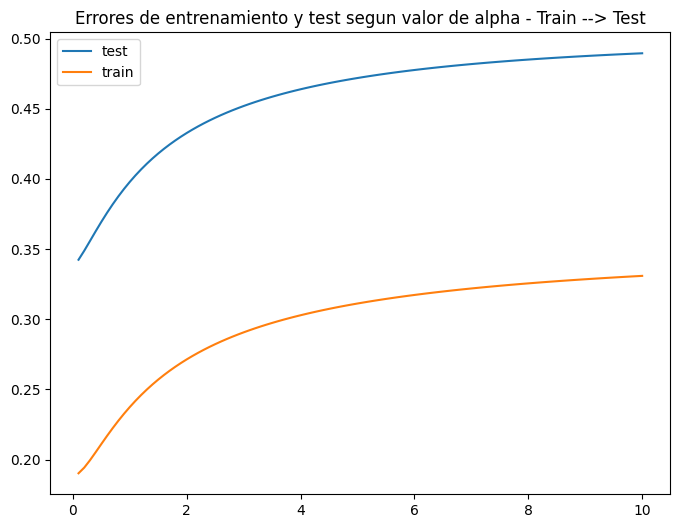

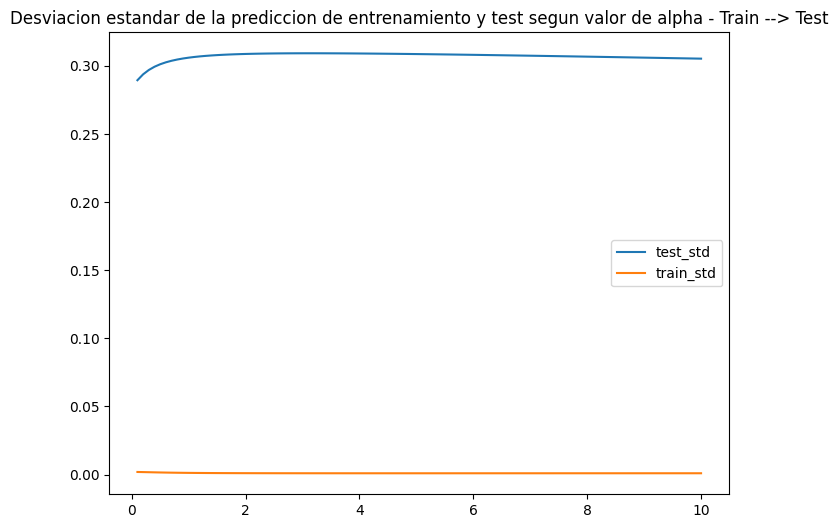

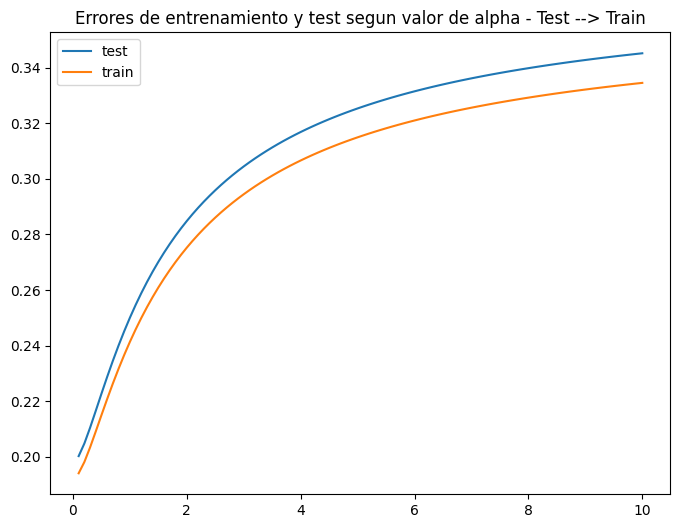

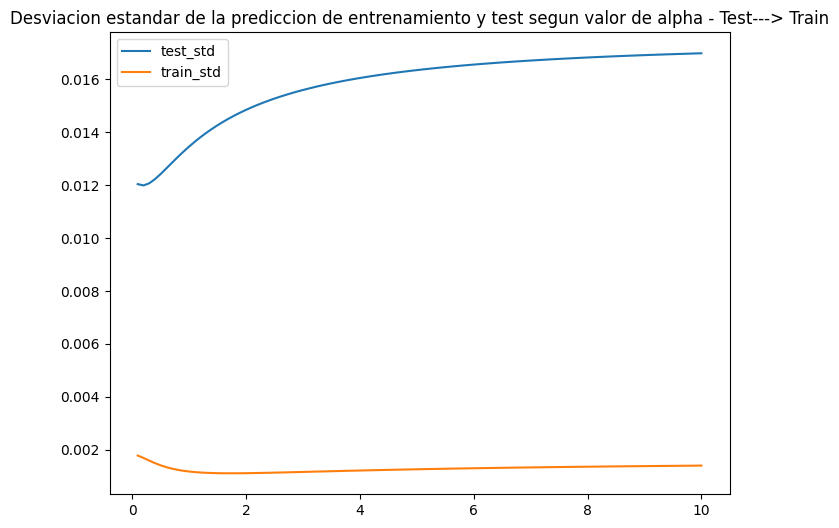

CPU times: user 3.73 s, sys: 1.16 s, total: 4.88 s
Wall time: 1min 8s


In [ ]:
%%time
parametros1 = {'alpha':np.arange(0.1, 10.1, 0.1)}

X1 = base_modelo.get([x for x in base_modelo.columns if x not in ["y"]])

y1 = base_modelo.get(["y"]).to_numpy()
# aplicar logaridmo para reducir la varianza y mejorar el ajuste del modelo
y1_log = np.log(y1)


opt1, rs1, mtrain, mtest, utrain, utest, opt2, rs2, mtrain2, mtest2, utrain2, utest2 = Rigde_grid(
X=X1,Y=y1_log,
size_test=0.5,seed_=19042023,
parametros1 = parametros1,
metric_=RMSE,k=5,graph=True)

In [79]:
print(opt1) # modelo 1 fit train predict test
print(opt2) # modelo 2 fit test predict train

{'alpha': np.float64(0.1)}
{'alpha': np.float64(0.1)}


### Métricas de error modelo 1 ví­a fit train predict test

In [80]:
print("Métricas de error:")
print(mtrain)
print(mtest) 

print("Métricas de umbral:")
print(utrain)
print(utest)

Métricas de error:
402347.8648437833
467880.2898379295
Métricas de umbral:
93.77443775824298
93.51376833698455


### Métricas de error modelo 2 ví­a fit test predict train

In [81]:
print("Métricas de error:")
print(mtrain2)
print(mtest2)

print("Métricas de umbral:")
print(utrain2)
print(utest2)

Métricas de error:
358167.48490405723
340827.322312958
Métricas de umbral:
93.49297024486287
93.68847231080669


### Modelo Lasso

In [ ]:
def Lasso_grid(X,Y,size_test,seed_,parametros1,metric_,k,graph=True):
    X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size = size_test, 
    random_state = seed_)
    
    P1 = preprocessing.StandardScaler()
    P1 = P1.fit(X_train)
    P2 = preprocessing.StandardScaler()
    P2 = P2.fit(Y_train)
    X_train_Z = P1.transform(X_train)
    X_test_Z = P1.transform(X_test)
    Y_train_Z = P2.transform(Y_train).ravel()
    Y_test_Z = P2.transform(Y_test).ravel()
    
    modelo1 = Lasso(max_iter=10000)
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1,
    return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    modelo2 = Lasso(max_iter=10000)
    grilla2 = GridSearchCV(estimator=modelo2, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla2=grilla2.fit(X_test_Z, Y_test_Z)
    
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1["mean_test_score"] = res1["mean_test_score"].map(abs)
    res1["mean_train_score"] = res1["mean_train_score"].map(abs)
    
    res2 = pd.DataFrame(grilla2.cv_results_)
    res2 = res2.get(['param_alpha','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res2["mean_test_score"] = res2["mean_test_score"].map(abs)
    res2["mean_train_score"] = res2["mean_train_score"].map(abs)
    
    if graph==True:
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["mean_test_score"])
        plt.plot(res1['param_alpha'],res1["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segun valor de alpha - Lasso Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res1['param_alpha'],res1["std_test_score"])
        plt.plot(res1['param_alpha'],res1["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("Desviacion estandar de la prediccion de entrenamiento y test segun valor de alpha - Lasso Train --> Test")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res2['param_alpha'],res2["mean_test_score"])
        plt.plot(res2['param_alpha'],res2["mean_train_score"])
        plt.legend(['test','train'])
        plt.title("Errores de entrenamiento y test segun valor de alpha - Lasso Test --> Train")
        plt.show()
        
        plt.figure(figsize=(8,6))
        plt.plot(res2['param_alpha'],res2["std_test_score"])
        plt.plot(res2['param_alpha'],res2["std_train_score"])
        plt.legend(['test_std','train_std'])
        plt.title("Desviacion estandar de la prediccion de entrenamiento y test segun valor de alpha - Lasso Test --> Train")
        plt.show()
    
    y_hat_train_Z = grilla1.predict(X_train_Z)
    #y_hat_train = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    y_hat_train_log = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))

    y_hat_test_Z = grilla1.predict(X_test_Z)
    #y_hat_test = P2.inverse_transform(y_hat_test_Z.reshape(-1, 1))
    y_hat_test_log = P2.inverse_transform(y_hat_test_Z.reshape(-1, 1))
   # aplica exponentes para representar el error y el umbral en valores logicos
    y_hat_train = np.exp(y_hat_train_log)
    y_hat_test = np.exp(y_hat_test_log)

    y_train_real = np.exp(Y_train)
    y_test_real = np.exp(Y_test)

    Error_Train = metric_(y_train_real,y_hat_train)
    Error_Test = metric_(y_test_real,y_hat_test)
    
    Umbral_train = umbral(y_train_real,y_hat_train)
    Umbral_test = umbral(y_test_real,y_hat_test)
    
    y_hat_train_Z2 = grilla2.predict(X_test_Z)
    #y_hat_train2 = P2.inverse_transform(y_hat_train_Z2.reshape(-1, 1))
    y_hat_train2_log = P2.inverse_transform(y_hat_train_Z2.reshape(-1, 1))

    y_hat_test_Z2 = grilla2.predict(X_train_Z)
    #y_hat_test2 = P2.inverse_transform(y_hat_test_Z2.reshape(-1, 1))
    y_hat_test2_log = P2.inverse_transform(y_hat_test_Z2.reshape(-1, 1))

    
    y_hat_train2 = np.exp(y_hat_train2_log)
    y_hat_test2 = np.exp(y_hat_test2_log)
    
    Error_Train2 = metric_(y_test_real,y_hat_train2)
    Error_Test2 = metric_(y_train_real,y_hat_test2)
    
    Umbral_train2 = umbral(y_test_real ,y_hat_train2)
    Umbral_test2 = umbral(y_train_real,y_hat_test2)
    
    return grilla1.best_params_, res1, Error_Train, Error_Test, Umbral_train, Umbral_test, grilla2.best_params_, res2, Error_Train2, Error_Test2, Umbral_train2, Umbral_test2


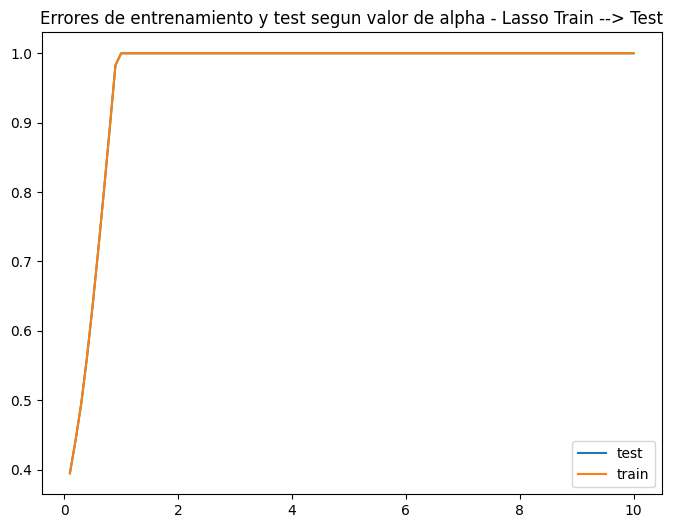

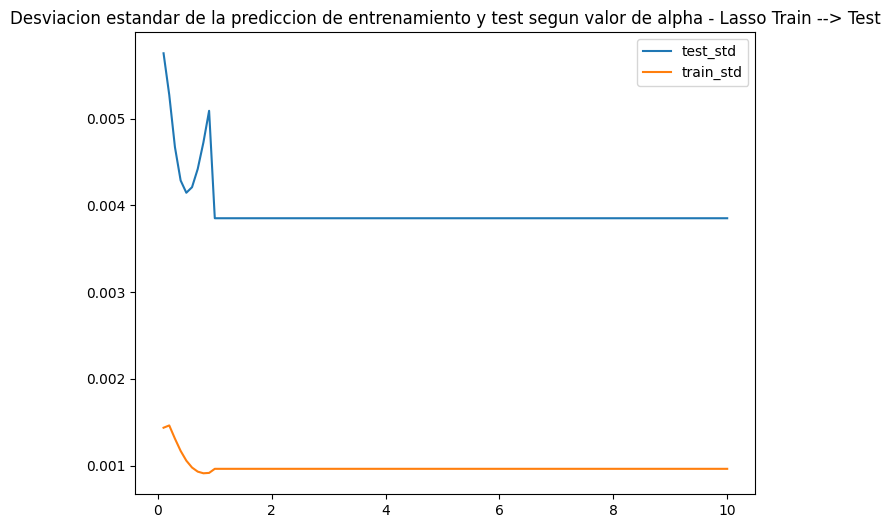

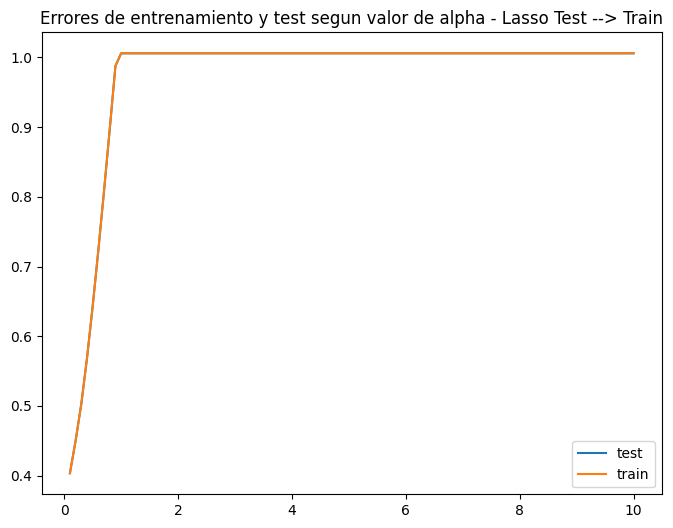

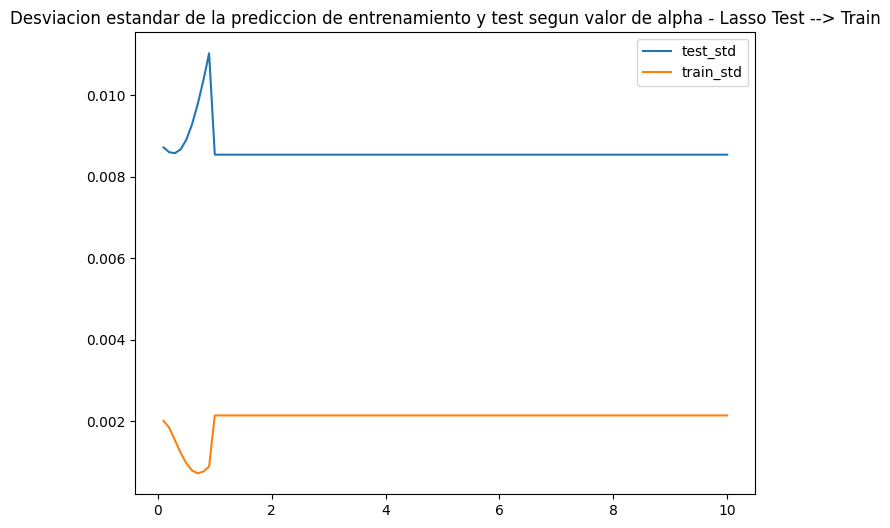

In [83]:
parametros1 = {'alpha':np.arange(0.1,10.1,0.1)}

X1 = base_modelo.get([x for x in base_modelo.columns if x not in ["y"]])
y1 = base_modelo.get(["y"]).to_numpy()
# aplicar logaridmo para reducir la varianza y mejorar el ajuste del modelo
y1_log = np.log(y1)

opt1_lasso, rs1_lasso, mtrain_lasso, mtest_lasso, utrain_lasso, utest_lasso, opt2_lasso, rs2, mtrain2_lasso, mtest2_lasso, utrain2_lasso, utest2_lasso = Lasso_grid(
X=X1,Y=y1_log,
size_test=0.5,seed_=19042023,
parametros1 = parametros1,
metric_=RMSE,k=5,graph=True)

In [84]:
print(opt1_lasso) # modelo 1 fit train predict test
print(opt2_lasso) # modelo 2 fit test predict train

{'alpha': np.float64(0.1)}
{'alpha': np.float64(0.1)}


In [85]:
print("Métricas de error:")
print(mtrain_lasso)
print(mtest_lasso)

print("Métricas de umbral:")
print(utrain_lasso)
print(utest_lasso)

Métricas de error:
903093.1106260861
1157591.2197560123
Métricas de umbral:
52.192118909625364
52.3529574886997


In [86]:
print("Métricas de error:")
print(mtrain2_lasso)
print(mtest2_lasso)

print("Métricas de umbral:")
print(utrain2_lasso)
print(utest2_lasso)

Métricas de error:
1156338.9468138658
901559.9538219211
Métricas de umbral:
52.027120712126674
51.88292060674967


### Elastic Net

In [ ]:
def ElasticNet_grid(X,Y,size_test,seed_,parametros1,metric_,k,graph=True):
    X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size = size_test, 
    random_state = seed_)
    
    P1 = preprocessing.StandardScaler()
    P1 = P1.fit(X_train)
    P2 = preprocessing.StandardScaler()
    P2 = P2.fit(Y_train)
    X_train_Z = P1.transform(X_train)
    X_test_Z = P1.transform(X_test)
    Y_train_Z = P2.transform(Y_train).ravel()
    Y_test_Z = P2.transform(Y_test).ravel()
    
    modelo1 = ElasticNet(max_iter=10000)
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1,
    return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    modelo2 = ElasticNet(max_iter=10000)
    grilla2 = GridSearchCV(estimator=modelo2, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla2=grilla2.fit(X_test_Z, Y_test_Z)
    
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','param_l1_ratio','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1['param_alpha'] = res1['param_alpha'].astype(float)
    res1['param_l1_ratio'] = res1['param_l1_ratio'].astype(float)
    res1['mean_test_score'] = res1['mean_test_score'].map(abs)
    res1['mean_train_score'] = res1['mean_train_score'].map(abs)
    
    res2 = pd.DataFrame(grilla2.cv_results_)
    res2 = res2.get(['param_alpha','param_l1_ratio','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res2['param_alpha'] = res2['param_alpha'].astype(float)
    res2['param_l1_ratio'] = res2['param_l1_ratio'].astype(float)
    res2['mean_test_score'] = res2['mean_test_score'].map(abs)
    res2['mean_train_score'] = res2['mean_train_score'].map(abs)
    
    if graph==True:
        fig, axes = plt.subplots(2,2, figsize=(14,10))
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_test_score'), cmap='viridis', ax=axes[0,0])
        axes[0,0].set_title('Error test - Elastic Net Train --> Test')
        axes[0,0].set_xlabel('alpha')
        axes[0,0].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_train_score'), cmap='viridis', ax=axes[0,1])
        axes[0,1].set_title('Error train - Elastic Net Train --> Test')
        axes[0,1].set_xlabel('alpha')
        axes[0,1].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='std_test_score'), cmap='magma', ax=axes[1,0])
        axes[1,0].set_title('Std test - Elastic Net Train --> Test')
        axes[1,0].set_xlabel('alpha')
        axes[1,0].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='std_train_score'), cmap='magma', ax=axes[1,1])
        axes[1,1].set_title('Std train - Elastic Net Train --> Test')
        axes[1,1].set_xlabel('alpha')
        axes[1,1].set_ylabel('l1_ratio')
        plt.tight_layout()
        plt.show()
        
        fig, axes = plt.subplots(2,2, figsize=(14,10))
        sns.heatmap(res2.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_test_score'), cmap='viridis', ax=axes[0,0])
        axes[0,0].set_title('Error test - Elastic Net Test --> Train')
        axes[0,0].set_xlabel('alpha')
        axes[0,0].set_ylabel('l1_ratio')
        sns.heatmap(res2.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_train_score'), cmap='viridis', ax=axes[0,1])
        axes[0,1].set_title('Error train - Elastic Net Test --> Train')
        axes[0,1].set_xlabel('alpha')
        axes[0,1].set_ylabel('l1_ratio')
        sns.heatmap(res2.pivot(index='param_l1_ratio', columns='param_alpha', values='std_test_score'), cmap='magma', ax=axes[1,0])
        axes[1,0].set_title('Std test - Elastic Net Test --> Train')
        axes[1,0].set_xlabel('alpha')
        axes[1,0].set_ylabel('l1_ratio')
        sns.heatmap(res2.pivot(index='param_l1_ratio', columns='param_alpha', values='std_train_score'), cmap='magma', ax=axes[1,1])
        axes[1,1].set_title('Std train - Elastic Net Test --> Train')
        axes[1,1].set_xlabel('alpha')
        axes[1,1].set_ylabel('l1_ratio')
        plt.tight_layout()
        plt.show()
    
    y_hat_train_Z = grilla1.predict(X_train_Z)
    #y_hat_train = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    y_hat_train_log = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    
    y_hat_test_Z = grilla1.predict(X_test_Z)
    #y_hat_test = P2.inverse_transform(y_hat_test_Z.reshape(-1, 1))
    y_hat_test_log = P2.inverse_transform(y_hat_test_Z.reshape(-1, 1))
    # aploica exponentes para representar el error y el umbral en valores logicos
    y_hat_train = np.exp(y_hat_train_log)
    y_hat_test = np.exp(y_hat_test_log)

    y_train_real = np.exp(Y_train)
    y_test_real = np.exp(Y_test)

    Error_Train = metric_(y_train_real,y_hat_train)
    Error_Test = metric_(y_test_real,y_hat_test)
    
    Umbral_train = umbral(y_train_real,y_hat_train)
    Umbral_test = umbral(y_test_real,y_hat_test)

    
    
    y_hat_train_Z2 = grilla2.predict(X_test_Z)
    #y_hat_train2 = P2.inverse_transform(y_hat_train_Z2.reshape(-1, 1))
    y_hat_train2_log = P2.inverse_transform(y_hat_train_Z2.reshape(-1, 1))
    
    y_hat_test_Z2 = grilla2.predict(X_train_Z)
    #y_hat_test2 = P2.inverse_transform(y_hat_test_Z2.reshape(-1, 1))
    y_hat_test2_log = P2.inverse_transform(y_hat_test_Z2.reshape(-1, 1))

    y_hat_train2 = np.exp(y_hat_train2_log)
    y_hat_test2 = np.exp(y_hat_test2_log)
    
    Error_Train2 = metric_(y_test_real,y_hat_train2)
    Error_Test2 = metric_(y_train_real,y_hat_test2)
    
    Umbral_train2 = umbral(y_test_real,y_hat_train2)
    Umbral_test2 = umbral(y_train_real,y_hat_test2)
    
    return grilla1.best_params_, res1, Error_Train, Error_Test, Umbral_train, Umbral_test, grilla2.best_params_, res2, Error_Train2, Error_Test2, Umbral_train2, Umbral_test2

def ElasticNet_grid_completed(X,Y,parametros1,metric_,k,graph=True):
    P1 = preprocessing.StandardScaler()
    P1 = P1.fit(X)
    P2 = preprocessing.StandardScaler()
    P2 = P2.fit(Y)
    X_train_Z = P1.fit_transform(X)
    Y_train_Z = P2.fit_transform(Y).ravel()
    
    modelo1 = ElasticNet(max_iter=10000)
    grilla1 = GridSearchCV(estimator=modelo1, param_grid=parametros1,
    scoring=make_scorer(metric_, greater_is_better=False), cv=k,n_jobs=-1, return_train_score=True)
    grilla1=grilla1.fit(X_train_Z, Y_train_Z)
    
    res1 = pd.DataFrame(grilla1.cv_results_)
    res1 = res1.get(['param_alpha','param_l1_ratio','mean_test_score','mean_train_score','std_test_score','std_train_score'])
    res1['param_alpha'] = res1['param_alpha'].astype(float)
    res1['param_l1_ratio'] = res1['param_l1_ratio'].astype(float)
    res1['mean_test_score'] = res1['mean_test_score'].map(abs)
    res1['mean_train_score'] = res1['mean_train_score'].map(abs)
    
    if graph==True:
        fig, axes = plt.subplots(2,2, figsize=(14,10))
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_test_score'), cmap='viridis', ax=axes[0,0])
        axes[0,0].set_title('Error test - Elastic Net Train --> Test')
        axes[0,0].set_xlabel('alpha')
        axes[0,0].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='mean_train_score'), cmap='viridis', ax=axes[0,1])
        axes[0,1].set_title('Error train - Elastic Net Train --> Test')
        axes[0,1].set_xlabel('alpha')
        axes[0,1].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='std_test_score'), cmap='magma', ax=axes[1,0])
        axes[1,0].set_title('Std test - Elastic Net Train --> Test')
        axes[1,0].set_xlabel('alpha')
        axes[1,0].set_ylabel('l1_ratio')
        sns.heatmap(res1.pivot(index='param_l1_ratio', columns='param_alpha', values='std_train_score'), cmap='magma', ax=axes[1,1])
        axes[1,1].set_title('Std train - Elastic Net Train --> Test')
        axes[1,1].set_xlabel('alpha')
        axes[1,1].set_ylabel('l1_ratio')
        plt.tight_layout()
        plt.show()
    
    y_hat_train_Z = grilla1.predict(X_train_Z)
    #y_hat_train = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    y_hat_train_log = P2.inverse_transform(y_hat_train_Z.reshape(-1, 1))
    # aplca exponentes para representar el error y el umbral en valores logicos
    y_hat_train = np.exp(y_hat_train_log)

    y_train_real = np.exp(Y)
    
    Error_Train = metric_(y_train_real,y_hat_train)
    Umbral_train = umbral(y_train_real,y_hat_train)
    
    return grilla1, grilla1.best_params_, res1, Error_Train, Umbral_train, P1, P2


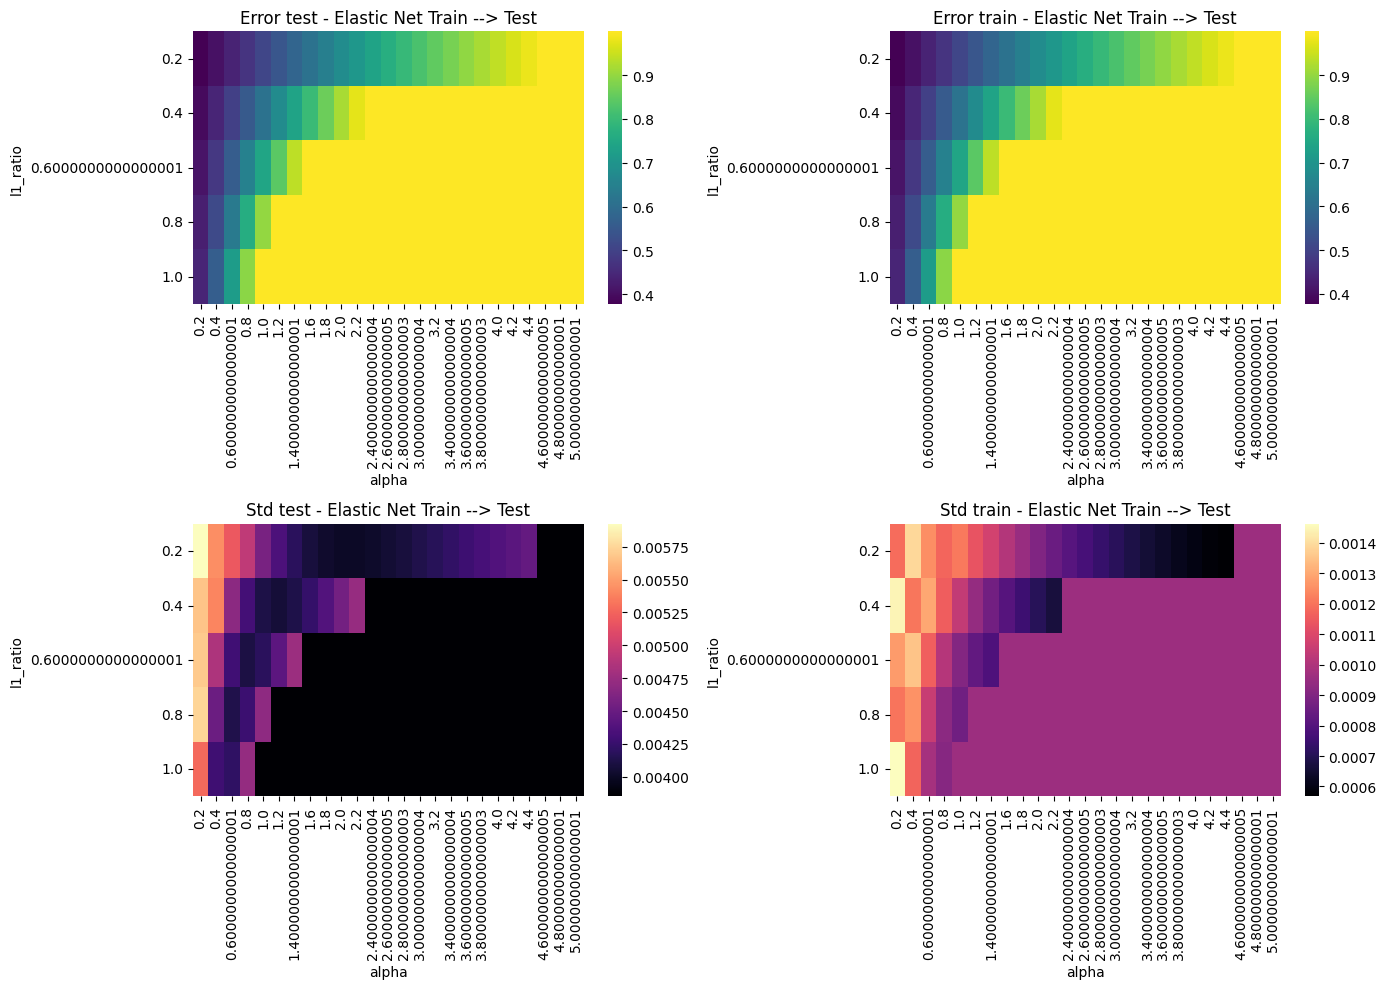

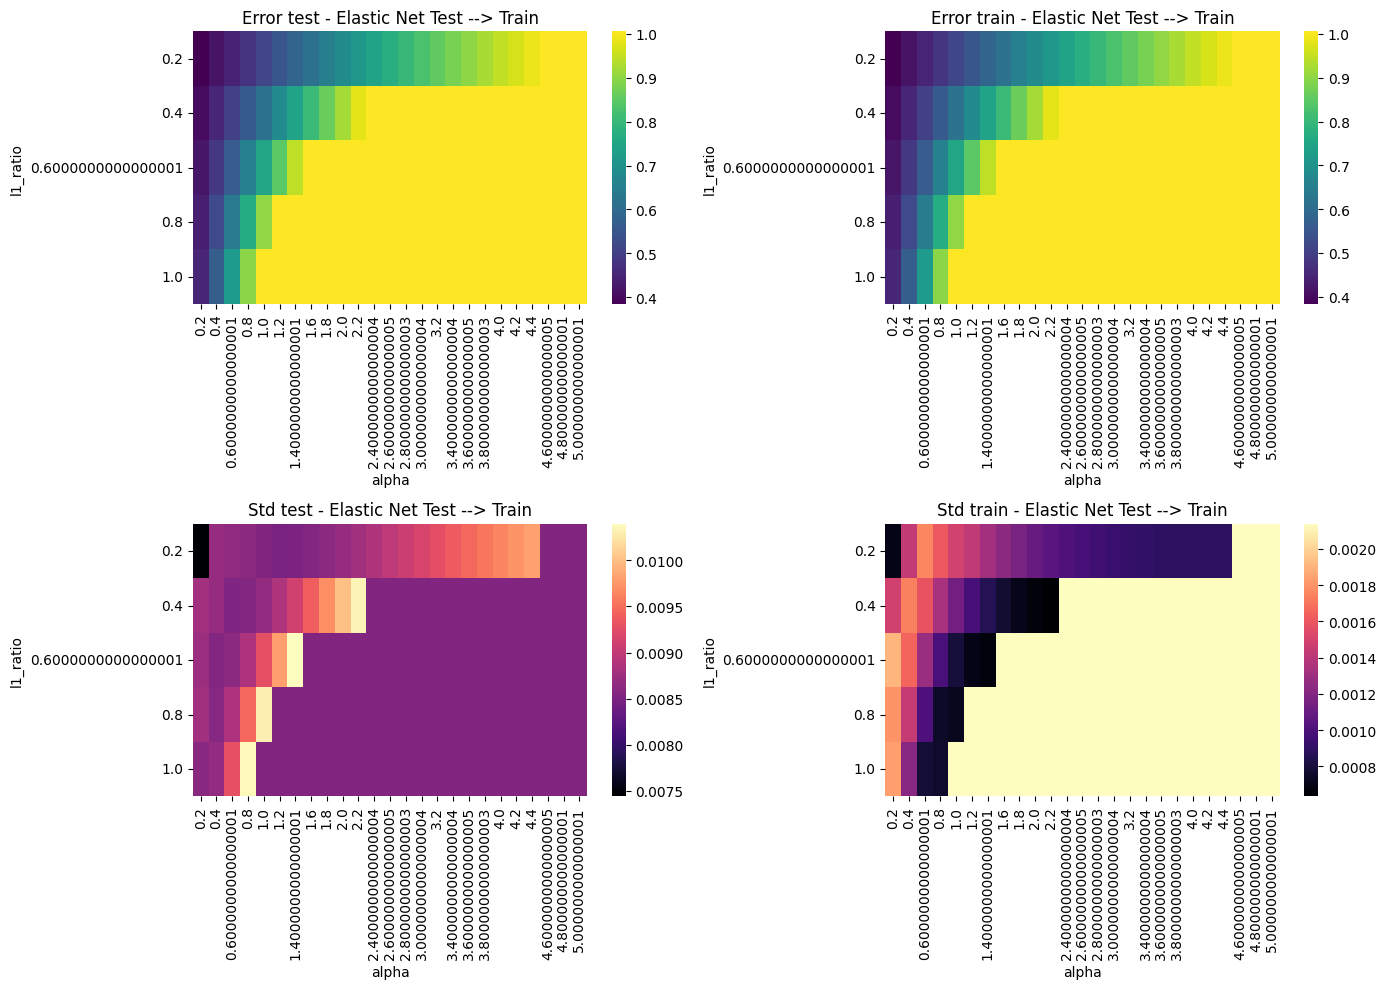

CPU times: user 10.1 s, sys: 2.57 s, total: 12.6 s
Wall time: 3min 14s


In [88]:
%%time
parametros1 = {'alpha':np.arange(0.2,5.2,0.2), 'l1_ratio':np.arange(0.2,1.2,0.2)}

X1 = base_modelo.get([x for x in base_modelo.columns if x not in ["y"]])
y1 = base_modelo.get(["y"]).to_numpy()
#aplicar logaridmo para reducir la varianza y mejorar el ajuste del modelo
y1_log = np.log(y1)

opt1_elastic, rs1_elastic, mtrain_elastic, mtest_elastic, utrain_elastic, utest_elastic, opt2_elastic, rs2_elastic, mtrain2_elastic, mtest2_elastic, utrain2_elastic, utest2_elastic = ElasticNet_grid(
X=X1,Y=y1_log,
size_test=0.5,seed_=19042023,
parametros1 = parametros1,
metric_=RMSE,k=5,graph=True)

In [89]:
print(opt1_elastic) # modelo 1 fit train predict test
print(opt2_elastic) # modelo 2 fit test predict train

{'alpha': np.float64(0.2), 'l1_ratio': np.float64(0.2)}
{'alpha': np.float64(0.2), 'l1_ratio': np.float64(0.2)}


In [90]:
print("Métricas de error:")
print(mtrain_elastic)
print(mtest_elastic)

print("Métricas de umbral:")
print(utrain_elastic)
print(utest_elastic)

Métricas de error:
893173.3543266234
1149525.1670651687
Métricas de umbral:
53.09475610770639
53.04900030503868


In [91]:
print("Métricas de error:")
print(mtrain2_elastic)
print(mtest2_elastic)

print("Métricas de umbral:")
print(utrain2_elastic)
print(utest2_elastic)

Métricas de error:
1103778.9415748704
862913.807150481
Métricas de umbral:
52.77307894955769
52.750894317961226


### Comparación de modelos

#### vía fit train predict test

In [92]:
pd.DataFrame({'modelo':["Ridge","Lasso","Elastic Net"], 'Error Train':[mtrain,mtrain_lasso,mtrain_elastic], 'Error Test':[mtest,mtest_lasso,mtest_elastic], 'Umbral Train':[utrain,utrain_lasso,utrain_elastic], 'Umbral Test':[utest,utest_lasso,utest_elastic]})

,modelo,Error Train,Error Test,Umbral Train,Umbral Test
0,Ridge,402347.864844,4.678803e+05,93.774438,93.513768
1,Lasso,903093.110626,1.157591e+06,52.192119,52.352957
2,Elastic Net,893173.354327,1.149525e+06,53.094756,53.049000


#### vía fit test predict train

In [93]:
pd.DataFrame({'modelo':["Ridge","Lasso","Elastic Net"], 'Error Train':[mtrain2,mtrain2_lasso,mtrain2_elastic], 'Error Test':[mtest2,mtest2_lasso,mtest2_elastic], 'Umbral Train':[utrain2,utrain2_lasso,utrain2_elastic], 'Umbral Test':[utest2,utest2_lasso,utest2_elastic]})

,modelo,Error Train,Error Test,Umbral Train,Umbral Test
0,Ridge,3.581675e+05,340827.322313,93.492970,93.688472
1,Lasso,1.156339e+06,901559.953822,52.027121,51.882921
2,Elastic Net,1.103779e+06,862913.807150,52.773079,52.750894


### Entrenamiento del mejor modelo completo

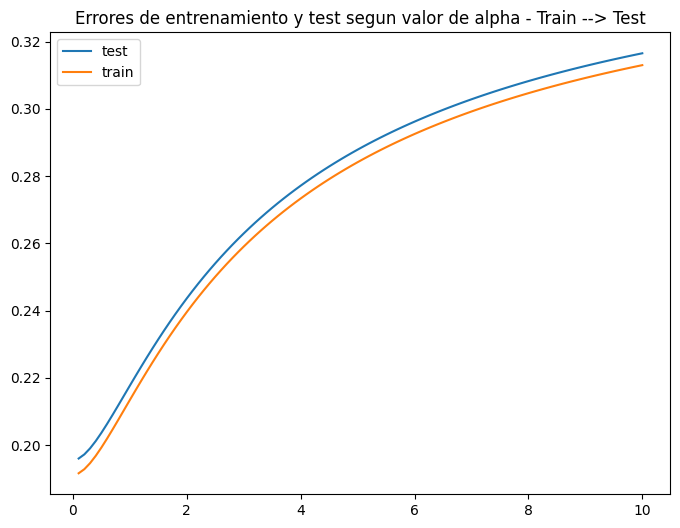

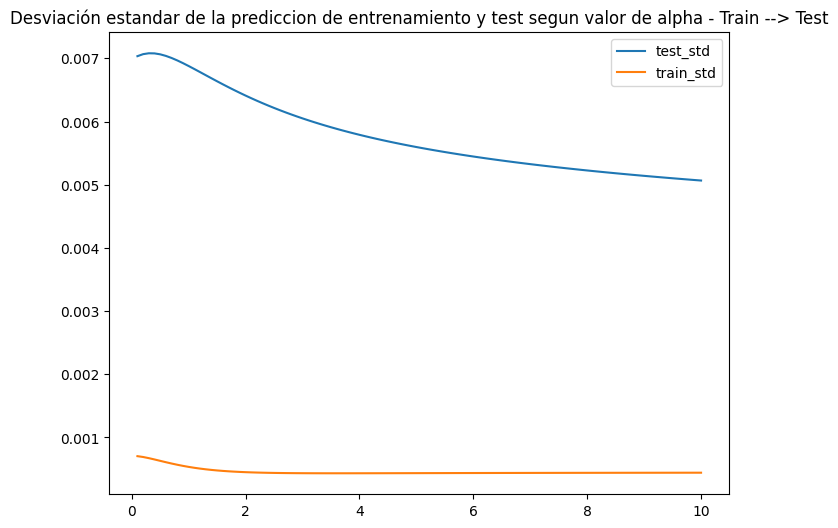

CPU times: user 2.38 s, sys: 700 ms, total: 3.08 s
Wall time: 48.1 s


In [94]:
%%time
parametros1 = {'alpha':np.arange(0.1,10.1,0.1)}

modelo1, opt, r1, mtrain1, mumbral1, trans1, trans2 = Rigde_grid_completed(
X=X1,Y=y1_log,
parametros1=parametros1,metric_=RMSE,k=5,graph=True)

In [95]:

print(mtrain1)
print(mumbral1)

384220.4934736637
93.67252710684674


# Exportar Modelo

In [96]:
path2 = "../databases/"

In [97]:
import pickle
with open(path2 + 'best_model_Ridge.pkl', 'wb') as model_file:
    pickle.dump(modelo1, model_file)

### Prediccion nuevos datos

In [98]:
prueba.head(2)

,PRECPREDIO,PRECCONS,PRECRESTO,PRETPROP,PRECLASE,PREMDIRECC,PREATERRE,PREACONST,PRECDESTIN,PREVETUSTZ,...,PREAFACHAD,PREACUBIER,PREAPISOS,PREACONS,PREBTAMANO,PREBENCHAP,Latitud,Longitud,ClaseBarrio,y
0,1.01,9,3003,6,P,D,27.53,82.1,1,1994,...,212.0,223.0,235.0,242.0,312.0,322,48,3.914221,1,599335.913749
1,1.01,4,5002,6,P,D,27.53,82.1,1,1994,...,212.0,223.0,235.0,242.0,312.0,322,48,3.914221,1,576293.145277


In [99]:
cuantitativas

['PRECPREDIO',
 'PRECCONS',
 'PRECRESTO',
 'PRETPROP',
 'PREATERRE',
 'PREACONST',
 'PRECDESTIN',
 'PREVETUSTZ',
 'PREVFORMA',
 'PREVACTUAL',
 'PRECUSO',
 'PREAUSO',
 'PREEARMAZ',
 'PREEMUROS',
 'PREECUBIER',
 'PREECONS',
 'PREAFACHAD',
 'PREACUBIER',
 'PREAPISOS',
 'PREACONS',
 'PREBTAMANO',
 'PREBENCHAP',
 'Latitud',
 'Longitud',
 'ClaseBarrio']

In [100]:
categoricas

['PRECLASE', 'PREMDIRECC', 'PREUSOPH', 'PREUSONPH', 'PREUVIVIEN', 'PREUCALIF']

In [101]:
# Variables cuantitativas (Activar D1)
D1 = prueba.get(cuantitativas).copy()

# Variables categÃ³ricas
D2 = prueba.get(categoricas).copy()
for k in categoricas:
  D2[k] = D2[k].map(nombre_)
D4 = D2.copy()

# Variables al cuadrado (Activar D1)
cuadrado = [re.findall(r'(.+)_\d+', item) for item in c2]
cuadrado = [x[0] for x in cuadrado]

for k in cuadrado:
  D1[k+"_2"] = D1[k] ** 2

# Interacciones cuantitativas (Activar D1)
result = [re.findall(r'([A-Za-z\s\(\)0-9]+)', item) for item in cxy]

for k in result:
  D1[k[0]+"__"+k[1]] = D1[k[0]] * D1[k[1]]

# Razones
result2 = [re.findall(r'(.+)__coc__(.+)', item) for item in razxy]
for k in result2:
  k2 = k[0]
  D1[k2[0]+"__coc__"+k2[1]] = D1[k2[0]] / (D1[k2[1]]+0.01)

# Interacciones categÃ³ricas
result3 = [re.search(r'([^_]+__[^_]+)', item).group(1).split('__') for item in catxy]
for k in result3:
  D4[k[0]+"__"+k[1]] = D4[k[0]] + "_" + D4[k[1]]

# InteracciÃ³n cuantitativa vs categÃ³rica
D5 = prueba.copy()
#result4 = [re.search(r'(.+?)_(.+?)_(.+)', item).groups() for item in cuactxy]
result4 = [re.search(r'(.+?)_(.+?)_(.+)', item).groups() for item in cuactxy]
contador = 0
for k in result4:
  col1, col2 = k[1], k[0] # categÃ³rica, cuantitativa
  if contador == 0:
    D51 = pd.get_dummies(D5[col1],drop_first=True)
    for j in D51.columns:
      D51[j] = D51[j] * D5[col2]
    D51.columns = [col2+"_"+col1+"_"+ str(x) for x in D51.columns]
  else:
    D52 = pd.get_dummies(D5[col1],drop_first=True)
    for j in D52.columns:
      D52[j] = D52[j] * D5[col2]
    D52.columns = [col2+"_"+col1+"_"+ str(x) for x in D52.columns]
    D51 = pd.concat([D51,D52],axis=1)
  contador = contador + 1

In [102]:
B1 = pd.concat([D1,D4],axis=1)
base_modelo_prueba = pd.concat([B1,D51],axis=1)
base_modelo_prueba.head(3)


,PRECPREDIO,PRECCONS,PRECRESTO,PRETPROP,PREATERRE,PREACONST,PRECDESTIN,PREVETUSTZ,PREVFORMA,PREVACTUAL,...,PREUSOPH,PREUSONPH,PREUVIVIEN,PREUCALIF,PREUSONPH__PREUVIVIEN,PREMDIRECC__PREUSONPH,PRECLASE__PREUVIVIEN,PREATERRE_PREUSOPH_S,PREATERRE_PREUVIVIEN_S,PREACONST_PRECLASE_P
0,1.01,9,3003,6,27.53,82.1,1,1994,1998,2024,...,CS,CN,CS,CA,CN_CS,CD_CN,CP_CS,27.53,27.53,82.1
1,1.01,4,5002,6,27.53,82.1,1,1994,1998,2024,...,CS,CN,CS,CA,CN_CS,CD_CN,CP_CS,27.53,27.53,82.1
2,1.01,17,2001,6,27.53,82.1,1,1994,1998,2024,...,CS,CN,CS,CA,CN_CS,CD_CN,CP_CS,27.53,27.53,82.1


In [103]:
len(base_modelo_prueba.columns)

43

In [104]:
len(base_modelo.columns)

44

In [105]:
base_modelo_prueba['PRECLASE'].dtypes

<StringDtype(storage='python', na_value=nan)>

In [106]:
column_object = [
"PRECLASE",
"PREMDIRECC",
"PREUSOPH",
"PREUSONPH",
"PREUVIVIEN",
"PREUCALIF",
"PREUSONPH__PREUVIVIEN",
"PREMDIRECC__PREUSONPH",
"PRECLASE__PREUVIVIEN"
]

for col in column_object:
    if col in transformadores_label:
        datos_col = base_modelo_prueba[col].astype(str)
        datos_col = datos_col.map(lambda s: s if s in transformadores_label[col].classes_ else transformadores_label[col].classes_[0])
        base_modelo_prueba[col] = transformadores_label[col].transform(datos_col)
    else:
        base_modelo_prueba[col] = transformadores_label[col].transform(base_modelo_prueba[col])
#    
base_modelo_prueba[column_object].head()

,PRECLASE,PREMDIRECC,PREUSOPH,PREUSONPH,PREUVIVIEN,PREUCALIF,PREUSONPH__PREUVIVIEN,PREMDIRECC__PREUSONPH,PRECLASE__PREUVIVIEN
0,1,0,1,0,1,0,1,0,3
1,1,0,1,0,1,0,1,0,3
2,1,0,1,0,1,0,1,0,3
3,1,0,1,0,1,0,1,0,3
4,1,0,1,0,1,0,1,0,3


In [107]:
Z1 = trans1
Z2 = trans2

X_prueba_z = Z1.transform(base_modelo_prueba)
y_prueba_pred_z = modelo1.predict(X_prueba_z)
y_prueba_pred = Z2.inverse_transform(np.array(y_prueba_pred_z).reshape(-1, 1)).ravel()

In [108]:
RMSE(np.log(prueba["y"]), y_prueba_pred)

np.float64(0.12803092177)

In [109]:
umbral(np.log(prueba["y"]), y_prueba_pred,umbral = param_umbral)

np.float64(99.9889990099109)

# Aanlisis y Conclusiones 


## Analisis

### 1. Los conjuntos de datos presentan una alta multidimensionalidad. Se identificó que variables de gestión (identificadores, direcciones exactas y fechas de registro) así como columnas con variables sin relacion predictivo para el  modelo, por lo que fueron depuradas para optimizar el costo computacional.

### 2. A la variable Clase_barrio se le aplicó un proceso de limpieza eliminando el prefijo `"Clase "` y transformándola en una variable cuantitativa, permitiendo que el algoritmo capture el orden jerárquico o nivel socioeconómico asociado a la clasificación del barrio.

### 3. La matriz de correlación inicial reveló que `PREACONST` (área construida) y `PREATERRE` (área de terreno) tienen la mayor influencia directa sobre la variable `y`.

### 4. La ingeniería de variables sobre las áreas físicas confirmó una relación de rendimientos marginales. Al generar términos cuadráticos de `PREACONST` y `PREATERRE`, el modelo logra identificar que el aumento del impuesto no siempre es lineal respecto al tamaño, capturando de forma más precisa la valorización de predios de gran extensión.

### 5. Se aplicó el principio de parsimonia mediante un análisis de importancia de variables que evaluó `interacciones` (cuantitativas y categóricas) y `razones`. Esto permitió seleccionar únicamente los predictores con mayor peso estadístico, buscando un modelo simplificado pero capaz de explicar más del 95% de la varianza del fenómeno catastral.

### 6. Para el procesamiento de variables categóricas complejas (como las interacciones en D4), se utilizó LabelEncoder y un diccionario de transformadores. Esto asegura que el contexto del negocio se mantenga en el modelo sin aumentar artificialmente la dimensión del conjunto de datos.

### 7. Se identificó que la variable `y` tenía mucha disparidad: hay muchos predios económicos y pocos predios con valores altísimos. Esta diferencia confundía al modelo y hacía que fallara en el objetivo de no errar por más del 15%. Para solucionarlo, aplicamos un logaritmo `np.log(y)`, lo que "comprimió" las distancias entre los valores, permitiendo que el modelo aprenda con la misma precisión tanto para una casa pequeña como para un edificio grande. Al final, regresamos el valor a escala de pesos con la función exponencial `np.exp()`, logrando predicciones mucho más estables y reales.

### 8. En la fase final, aplicamos una estandarización `StandardScaler` a todos los datos de entrada y a la variable de impuestos ya transformada. Esto sirvió para que todas las variables tuvieran el mismo peso, evitando que las de valores más grandes dominaran a las pequeñas. Gracias a esto, la validación cruzada en los tres modelos pudo elegir de forma justa el mejor ajuste (alpha), asegurando que, al volver a pesos reales, el margen de error fuera el mínimo posible.

## Conclusiones 

### 1. se puede concluir que la fase de Análisis Exploratorio de Datos resultó ser un proceso determinante. La identificación de la alta dispersión y varianza en la variable objetivo `y` llevó a la implementación estratégica de una transformación logarítmica. Esta decisión no solo estabilizó la varianza, sino que alineó el entrenamiento del modelo con una métrica de error relativo porcentual. Sin este análisis previo, las predicciones de valor de los predios habrían carecido de robustez, especialmente en los extremos del mercado

### 2. La evaluación sistemática de los tres modelos de regularización `Ridge, Lasso y Elastic Net`, utilizando una división `50% train` - `50% test` y validación cruzada inversa `test->train`, mostró de manera contundente la superioridad del modelo de Ridge. Los resultados, revelan que Ridge es el modelo más estable y preciso. En ambos flujos de validación, alcanzó un umbral de precisión superior al 93% en la muestra de test, superando ampliamente a Lasso y Elastic Net, que se mantuvieron estables pero en un nivel de precisión mucho más bajo alrededor del 52% al 53%. Esta consistencia en los resultados, independientemente de la partición de los datos, validó a Ridge como la opción más segura y eficiente para la predicción del impuesto predial.

### 3.  por ultimo la ejecución completa del modelo Ridge, logró un RMSE de aproximadamente 384,220 y un umbral de precisión del 93.67% sobre el conjunto completo de datos. Este elevado porcentaje de precisión, calculado sobre valores reales en pesos, hace que la herramienta sea fiable, cumpliendo con la meta de que más de 9 de cada 10 predios tengan una estimación de impuesto con un error menor al 15%.



